# **UrbanVox Prototype Version (Standard Process)**
This app is built for accomplishing the mini project task given in Geospatial Computation 2026 class from Geomatic Engineering Master Degree of Universitas Gadjah Mada, Yogyakarta

The people who collaborate in this project are Mesak Ananias, Sri Windari, Rachmanita Isna, Triawan, Hyatma Adikara, & Leonardo Brian

**The Standard Features --> No Spatiotemporal Analysis**

## **1. Pre-Processing (Library, Data, 3D Model)**

### 1.1. Install Environment

In [2]:
# 1.1 Install Core Packages
# ─────────────────────────────────────────────────────────────────
# This cell installs all the Python libraries needed by this notebook.
# Run this cell FIRST before anything else.
# It only needs to run once per Colab session.
# ─────────────────────────────────────────────────────────────────

import sys
import subprocess
import importlib

# ── Package list ──────────────────────────────────────────────
# Format: (import_name, pip_install_spec)
# Pinned minimum versions prevent silent compatibility breaks
# between Colab sessions.
PACKAGES = [
    ("voxcity",     "voxcity"),
    ("osmnx",       "osmnx>=1.9"),
    ("geopandas",   "geopandas>=0.14"),
    ("networkx",    "networkx>=3.2"),
    ("momepy",      "momepy>=0.7"),
    ("rasterio",    "rasterio>=1.3"),
    ("contextily",  "contextily>=1.5"),
    ("pyproj",      "pyproj>=3.6"),
    ("shapely",     "shapely>=2.0"),
    ("folium",      "folium>=0.16"),
    ("numpy",       "numpy>=1.26"),
    ("pandas",      "pandas>=2.1"),
    ("scipy",       "scipy>=1.12"),
    ("requests",    "requests>=2.31"),
    ("tqdm",        "tqdm>=4.66"),
]

# ── Step 1: Install Python packages ───────────────────────────
print("📦 Checking and installing Python packages...\n")
failed = []

for import_name, pip_spec in PACKAGES:
    try:
        importlib.import_module(import_name)
        print(f"  ✅  {import_name:<15} already installed")
    except ImportError:
        print(f"  ⬇️   {import_name:<15} installing...", end=" ", flush=True)
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pip_spec, "-q"],
            capture_output=True,
            text=True
        )
        if result.returncode == 0:
            print("done ✅")
        else:
            print("FAILED ❌")
            failed.append(pip_spec)

# ── Step 2: System dependencies for headless 3D rendering ─────
print("\n🖥️  Installing system dependencies (xvfb, libgl1)...")
subprocess.run(
    "apt-get -qq update && apt-get -qq install -y xvfb libgl1-mesa-glx",
    shell=True,
    capture_output=True
)

# ── Step 3: Launch virtual display ────────────────────────────
# Required for voxcity's 3D rendering to work in a headless
# Colab environment (no physical screen attached).
import os
subprocess.run("pkill Xvfb 2>/dev/null; sleep 1", shell=True, capture_output=True)
subprocess.run("Xvfb :99 -screen 0 1024x768x24 &", shell=True)
os.environ["DISPLAY"] = ":99"
print("  ✅  Virtual display :99 started")

# ── Step 4: Final status ───────────────────────────────────────
print("\n" + "─" * 55)
if failed:
    print(f"⚠️  WARNING: {len(failed)} package(s) failed to install:")
    for f in failed:
        print(f"   • {f}")
    print("   → Try re-running this cell, or install them manually.")
else:
    print("🎉 All packages installed. Proceed to Section 1.2.")
print("─" * 55)

📦 Checking and installing Python packages...

  ✅  voxcity         already installed
  ✅  osmnx           already installed
  ✅  geopandas       already installed
  ✅  networkx        already installed
  ✅  momepy          already installed
  ✅  rasterio        already installed
  ✅  contextily      already installed
  ✅  pyproj          already installed
  ✅  shapely         already installed
  ✅  folium          already installed
  ✅  numpy           already installed
  ✅  pandas          already installed
  ✅  scipy           already installed
  ✅  requests        already installed
  ✅  tqdm            already installed

🖥️  Installing system dependencies (xvfb, libgl1)...
  ✅  Virtual display :99 started

───────────────────────────────────────────────────────
🎉 All packages installed. Proceed to Section 1.2.
───────────────────────────────────────────────────────


### 1.2. Imports and Helpers

In [3]:
# @title 1.2.1. Import Libraries
# ─────────────────────────────────────────────────────────────────
# This cell loads all Python libraries used in the notebook.
# You do not need to change anything here.
# ─────────────────────────────────────────────────────────────────

import os
import sys
import math
import glob
import warnings
from pathlib import Path

# ── Standard scientific stack ─────────────────────────────────
import numpy as np
import pandas as pd
import scipy

# ── Geospatial stack ──────────────────────────────────────────
import geopandas as gpd
import networkx as nx
import osmnx as ox
import momepy
import rasterio
from pyproj import CRS, Transformer
from shapely.geometry import Polygon, Point, LineString, MultiLineString
from shapely.ops import unary_union

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import folium
import branca.colormap as bcm
from folium.plugins import Fullscreen
from folium.raster_layers import ImageOverlay

# ── IPython display utilities ─────────────────────────────────
from IPython.display import display, Image, Markdown, HTML, clear_output

# ── Google Colab detection ────────────────────────────────────
# Determines runtime environment for path and auth handling.
# IN_COLAB = True  → running on Google Colab
# IN_COLAB = False → running on local Jupyter / VS Code
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

# ── VoxCity core imports ───────────────────────────────────────
# If any VoxCity submodule fails, the error is caught individually
# so the rest of the notebook can still load partially.
_voxcity_ok = True
try:
    from voxcity.generator import get_voxcity
    from voxcity.geoprocessor.draw import draw_rectangle_map_cityname
except ImportError as e:
    print(f"  ❌ voxcity.generator / geoprocessor failed: {e}")
    _voxcity_ok = False

try:
    from voxcity.simulator.solar import (
        get_global_solar_irradiance_using_epw,
        get_building_global_solar_irradiance_using_epw,
    )
    from voxcity.simulator.visibility import (
        get_view_index,
        get_surface_view_factor,
    )
except ImportError as e:
    print(f"  ❌ voxcity.simulator failed: {e}")
    _voxcity_ok = False

try:
    from voxcity.visualizer import visualize_voxcity
except ImportError as e:
    print(f"  ❌ voxcity.visualizer failed: {e}")
    _voxcity_ok = False

try:
    from voxcity.exporter.envimet   import export_inx, generate_edb_file
    from voxcity.exporter.magicavoxel import export_magicavoxel_vox
    from voxcity.exporter.obj       import export_obj
    from voxcity.exporter.cityles   import export_cityles
except ImportError as e:
    print(f"  ❌ voxcity.exporter failed: {e}")
    _voxcity_ok = False

# ── Global settings ───────────────────────────────────────────
warnings.filterwarnings("ignore")
ox.settings.use_cache   = True
ox.settings.log_console = False

# ── Version snapshot (for reproducibility & debugging) ────────
# Logged once so that if results differ between sessions,
# you can trace it back to a library version change.
_versions = {
    "python":     sys.version.split()[0],
    "numpy":      np.__version__,
    "pandas":     pd.__version__,
    "geopandas":  gpd.__version__,
    "osmnx":      ox.__version__,
    "networkx":   nx.__version__,
    "shapely":    __import__("shapely").__version__,
    "scipy":      scipy.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "folium":     folium.__version__,
}

# ── Final status ──────────────────────────────────────────────
print("─" * 50)
print("  UrbanVox Standard — Libraries")
print("─" * 50)
print(f"  Runtime  : {'Google Colab' if IN_COLAB else 'Local Jupyter / VS Code'}")
print(f"  Python   : {_versions['python']}")
print(f"  NumPy    : {_versions['numpy']}")
print(f"  GeoPandas: {_versions['geopandas']}")
print(f"  OSMnx    : {_versions['osmnx']}")
print(f"  VoxCity  : {'✅ all modules loaded' if _voxcity_ok else '⚠️  some modules failed (see above)'}")
print("─" * 50)
print("✅ Section 1.2.1 complete. Proceed to 1.2.2.")

──────────────────────────────────────────────────
  UrbanVox Standard — Libraries
──────────────────────────────────────────────────
  Runtime  : Google Colab
  Python   : 3.12.13
  NumPy    : 2.0.2
  GeoPandas: 1.1.3
  OSMnx    : 2.1.0
  VoxCity  : ✅ all modules loaded
──────────────────────────────────────────────────
✅ Section 1.2.1 complete. Proceed to 1.2.2.


In [4]:
#@title 1.2.2 Helper Utility Functions
# ─────────────────────────────────────────────────────────────────
# This cell defines reusable helper functions used throughout the
# notebook. You do not need to edit this cell.
# ─────────────────────────────────────────────────────────────────

def ensure_dir(path):
    """Create a folder if it doesn't already exist."""
    Path(path).mkdir(parents=True, exist_ok=True)
    return path

def rect_to_polygon(vertices):
    """Convert a list of (lon, lat) corner points into a Shapely polygon."""
    return Polygon(vertices)

# ── Normalization ─────────────────────────────────────────────

def minmax_norm(series, clip_q=(0.02, 0.98)):
    """
    Normalize a pandas Series to [0, 1], clipping extreme outliers.

    Formula:
        x_clipped = clip(x, Q_low, Q_high)
        x_norm    = (x_clipped - Q_low) / (Q_high - Q_low + ε)

    Edge cases handled:
        - All NaN      → returns Series of NaN
        - Flat range   → returns Series of 0.0 (not NaN)
        - Inf values   → replaced with NaN before processing
    """
    s = pd.Series(series).astype(float).replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)
    low  = s.quantile(clip_q[0])
    high = s.quantile(clip_q[1])
    if pd.isna(low) or pd.isna(high) or np.isclose(high, low):
        # Flat or degenerate range → assign uniform score of 0
        return pd.Series(0.0, index=s.index)
    return (s.clip(lower=low, upper=high) - low) / (high - low)


def safe_array(arr, dtype=float):
    """Safely convert any array-like object to a NumPy array."""
    if arr is None:
        return None
    return np.asarray(arr, dtype=dtype)


def safe_norm(arr):
    """
    Normalize a NumPy array to [0, 1] range.

    Formula:
        x_norm = (x - x_min) / (x_max - x_min + ε)

    Edge cases handled:
        - All-NaN array → returns zeros (avoids nanmin crash)
        - Flat array    → returns zeros
    """
    arr = safe_array(arr, dtype=float)
    # Guard: all-NaN crashes np.nanmin
    if np.all(np.isnan(arr)):
        return np.zeros_like(arr, dtype=float)
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if np.isclose(arr_max, arr_min):
        return np.zeros_like(arr, dtype=float)
    return (arr - arr_min) / (arr_max - arr_min + 1e-9)


# ── Geometry ──────────────────────────────────────────────────

def edge_bearing(geom):
    """Calculate the compass bearing (0–360°) of a line geometry."""
    if geom is None:
        return np.nan
    if geom.geom_type == "MultiLineString":
        geom = list(geom.geoms)[0]
    coords = list(geom.coords)
    if len(coords) < 2:
        return np.nan
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return (math.degrees(math.atan2((x2 - x1), (y2 - y1))) + 360) % 360


def angular_alignment(bearing_deg, wind_deg):
    """
    Return how well a road bearing aligns with the wind direction (0–1).

    A street carries wind in BOTH directions (bidirectional), so we
    compare the street against both the wind direction and its reverse
    (wind + 180°), then take the best match.

    Formula:
        diff_fwd = |bearing - wind_deg|         folded to [0°, 180°]
        diff_rev = |bearing - (wind_deg + 180°)| folded to [0°, 180°]
        min_diff = min(diff_fwd, diff_rev)       now in [0°, 90°]

        alignment = 1 - (min_diff / 90)          scaled to [0, 1]

    Fix vs. previous version:
        The old formula used a single abs() difference which produced
        wrong results near the 0°/360° wrap boundary.
        Example — bearing=5°, wind=355°:
            Old: diff = |5 - 355| % 360 = 350° → alignment ≈ 0.06  ❌
            New: diff = fold(5 - 355) = 10°    → alignment ≈ 0.89  ✅
    """
    if pd.isna(bearing_deg):
        return np.nan

    def fold(angle):
        """Fold any angle difference into [0°, 180°]."""
        a = abs(angle % 360)
        return min(a, 360 - a)

    diff_fwd = fold(bearing_deg - wind_deg)
    diff_rev = fold(bearing_deg - (wind_deg + 180))
    min_diff = min(diff_fwd, diff_rev)   # guaranteed [0°, 90°]
    return float(1.0 - (min_diff / 90.0))


def print_stage(title):
    """Print a clearly visible section header."""
    print("\n" + "=" * 70)
    print(f"  {title}")
    print("=" * 70)


def polygon_area_km2(geom_or_gdf):
    """
    Return the area of a polygon in square kilometers.

    Uses the geometry's native UTM zone (auto-detected from centroid)
    instead of EPSG:3857 (Web Mercator), which distorts area
    significantly at latitudes away from the equator.

    Formula:
        zone   = floor((lon + 180) / 6) + 1
        EPSG   = 32700 + zone  (Southern Hemisphere)
               = 32600 + zone  (Northern Hemisphere)
        area   = projected_area / 1,000,000  [m² → km²]
    """
    geom = geom_or_gdf.unary_union if hasattr(geom_or_gdf, "unary_union") else geom_or_gdf
    gdf  = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")

    # Auto-detect UTM zone from centroid
    centroid  = gdf.geometry.iloc[0].centroid
    lon, lat  = centroid.x, centroid.y
    zone      = int((lon + 180) / 6) + 1
    epsg_utm  = (32600 if lat >= 0 else 32700) + zone

    gdf_proj = gdf.to_crs(epsg_utm)
    return float(gdf_proj.area.iloc[0] / 1e6)


# ── Network ───────────────────────────────────────────────────

def summarize_graph(G):
    """
    Return a dictionary with basic network statistics.

    Metrics returned:
        nodes           : total intersection count
        edges           : total street segment count
        avg_degree      : mean node connectivity
                          (higher = more grid-like, more route choices)
        total_length_km : sum of all edge lengths in km
                          (useful for walkability density reporting)
    """
    U = ox.convert.to_undirected(G)
    if U.number_of_nodes() == 0:
        return {"nodes": 0, "edges": 0,
                "avg_degree": np.nan, "total_length_km": 0.0}

    lengths = [
        d.get("length", 0)
        for _, _, d in U.edges(data=True)
    ]
    return {
        "nodes":           U.number_of_nodes(),
        "edges":           U.number_of_edges(),
        "avg_degree":      round(np.mean([d for _, d in U.degree()]), 3),
        "total_length_km": round(sum(lengths) / 1000, 3),
    }


def safe_features_from_polygon(polygon, tags):
    """Download OSM features within a polygon. Returns empty GDF if none found."""
    try:
        gdf = ox.features_from_polygon(polygon, tags)
        if isinstance(gdf.index, pd.MultiIndex):
            gdf = gdf.reset_index()
        return gdf
    except Exception as e:
        print(f"  ⚠️  No features found for tags {tags}: {e}")
        return gpd.GeoDataFrame(
            columns=["geometry"], geometry="geometry", crs="EPSG:4326"
        )


def nearest_distance_clean(source_gdf, target_gdf, max_dist_m=2000.0):
    """
    Find the nearest distance (m) from each source geometry to any target.

    Parameters
    ----------
    source_gdf  : GeoDataFrame — origins (any metric CRS)
    target_gdf  : GeoDataFrame — targets (any CRS, auto-reprojected)
    max_dist_m  : float — cap distance when no target exists (default 2000m)
                  Prevents NaN from propagating into index scores when
                  a feature type (e.g. parks) is absent from the AOI.

    Returns
    -------
    pd.Series — distance in meters, indexed like source_gdf
    """
    if target_gdf is None or len(target_gdf) == 0:
        # Return capped distance instead of NaN so downstream
        # normalization doesn't silently produce NaN index scores
        return pd.Series(max_dist_m, index=source_gdf.index, dtype=float)

    src = source_gdf[["geometry"]].dropna()
    tgt = target_gdf[["geometry"]].dropna()
    if tgt.crs != src.crs:
        tgt = tgt.to_crs(src.crs)

    joined = gpd.sjoin_nearest(src, tgt, how="left", distance_col="dist_m")
    dist   = joined.groupby(level=0)["dist_m"].min()
    return (
        dist.reindex(source_gdf.index)
            .fillna(max_dist_m)   # cap missing → max_dist_m, not NaN
            .astype(float)
    )


def array_summary_df(arr, label, extra_rows=None):
    """Build a simple summary table (min, mean, median, max) for a 2D array."""
    arr  = safe_array(arr, dtype=float)
    rows = [
        {"metric": "Index",             "value": label},
        {"metric": "Shape (rows × cols)", "value": f"{arr.shape[0]} × {arr.shape[1]}"},
        {"metric": "Min",    "value": round(float(np.nanmin(arr)),    3)},
        {"metric": "Mean",   "value": round(float(np.nanmean(arr)),   3)},
        {"metric": "Median", "value": round(float(np.nanmedian(arr)), 3)},
        {"metric": "Max",    "value": round(float(np.nanmax(arr)),    3)},
    ]
    if extra_rows:
        rows.extend(extra_rows)
    return pd.DataFrame(rows)


def save_folium_map(map_obj, output_path, label=None):
    """Save a Folium map as an HTML file."""
    if map_obj is None:
        return None
    ensure_dir(str(Path(output_path).parent))
    map_obj.save(str(output_path))
    if label:
        print(f"  💾 {label} → {output_path}")
    return output_path


def save_numpy_grid(arr, output_path, label=None):
    """Save a NumPy array to a .npy file."""
    if arr is None:
        return None
    ensure_dir(str(Path(output_path).parent))
    np.save(str(output_path), np.asarray(arr))
    if label:
        print(f"  💾 {label} → {output_path}")
    return output_path


# ── Interactive map builders ──────────────────────────────────

def make_interactive_base_map(aoi_gdf, green_areas=None, zoom_start=16):
    """Create a base Folium map centered on the AOI."""
    aoi_map = aoi_gdf.to_crs(4326).copy()
    minx, miny, maxx, maxy = aoi_map.total_bounds
    center_lat = (miny + maxy) / 2
    center_lon = (minx + maxx) / 2
    bounds     = [[miny, minx], [maxy, maxx]]

    m = folium.Map(location=[center_lat, center_lon], zoom_start=zoom_start,
                   tiles=None, control_scale=True)
    Fullscreen(position="topleft").add_to(m)

    folium.TileLayer("CartoDB positron", name="Basemap (Light)",
                     overlay=False, control=True, show=True).add_to(m)
    folium.TileLayer("OpenStreetMap", name="Basemap (OSM)",
                     overlay=False, control=True, show=False).add_to(m)
    folium.GeoJson(aoi_map, name="AOI Boundary",
                   style_function=lambda x: {
                       "color": "black", "weight": 2, "fillOpacity": 0
                   }, show=True).add_to(m)

    if green_areas is not None and not green_areas.empty:
        green_map = green_areas[green_areas.geometry.notna()].copy().to_crs(4326)
        folium.GeoJson(green_map, name="Green Areas",
                       style_function=lambda x: {
                           "color": "#7fbf7b", "weight": 1,
                           "fillColor": "#7fbf7b", "fillOpacity": 0.25
                       }, show=True).add_to(m)
    return m, bounds


def array_to_rgba(arr, cmap_name="viridis", flip_vertical=True):
    """
    Convert a 2D NumPy array to an RGBA image for Folium ImageOverlay.

    Uses matplotlib.colormaps[name] instead of the deprecated
    cm.get_cmap(name) which raises a warning in Matplotlib >= 3.9.
    """
    arr     = safe_array(arr, dtype=float)
    arr_min = float(np.nanmin(arr))
    arr_max = float(np.nanmax(arr))
    if np.isclose(arr_min, arr_max):
        arr_min, arr_max = 0.0, 1.0

    arr_norm = np.clip((arr - arr_min) / (arr_max - arr_min + 1e-9), 0, 1)

    # ✅ Use colormaps[] — works on Matplotlib >= 3.7, avoids deprecation
    cmap     = plt.colormaps[cmap_name]
    rgba_img = (cmap(arr_norm) * 255).astype(np.uint8)

    # Transparent where original data was NaN
    rgba_img[np.isnan(arr), 3] = 0
    if flip_vertical:
        rgba_img = np.flipud(rgba_img)
    return rgba_img, arr_min, arr_max


def finalize_map(m, bounds, legend_html=None, colormap=None):
    """Add layer control, colorbar, and legend to a Folium map."""
    m.fit_bounds(bounds)
    folium.LayerControl(collapsed=False).add_to(m)
    if colormap is not None:
        colormap.add_to(m)
    if legend_html:
        m.get_root().html.add_child(folium.Element(legend_html))
    return m


def make_raster_map(arr, aoi_gdf, green_areas=None, caption="Index",
                    cmap_name="viridis", overlay_name="Raster", opacity=0.75):
    """Build an interactive map with a single raster overlay."""
    arr      = safe_array(arr, dtype=float)
    rgba_img, vmin, vmax = array_to_rgba(arr, cmap_name=cmap_name)
    m, bounds = make_interactive_base_map(aoi_gdf, green_areas=green_areas)
    ImageOverlay(image=rgba_img, bounds=bounds, name=overlay_name,
                 opacity=opacity, interactive=False, zindex=3).add_to(m)

    # ✅ Use colormaps[] — avoids Matplotlib 3.9 deprecation warning
    cmap_obj = plt.colormaps[cmap_name]
    colormap = bcm.LinearColormap(
        colors=[cmap_obj(x) for x in np.linspace(0, 1, 6)],
        vmin=vmin, vmax=vmax, caption=caption
    )
    return finalize_map(m, bounds, colormap=colormap)


def make_multiraster_map(layer_specs, aoi_gdf, green_areas=None,
                          zoom_start=16, title="UrbanVox 2D Viewer"):
    """
    Build a combined interactive map with multiple switchable raster layers.

    Fix vs. previous version:
        The first valid layer now has show=True by default so the user
        sees a populated map immediately instead of a blank canvas.
        Individual specs can still override with show=False.
    """
    valid = [
        s for s in layer_specs
        if s.get("arr") is not None
        and not np.isnan(safe_array(s["arr"], float)).all()
    ]
    if not valid:
        raise ValueError("No valid raster layers provided.")

    m, bounds  = make_interactive_base_map(
        aoi_gdf, green_areas=green_areas, zoom_start=zoom_start
    )
    layer_infos = []

    for idx, spec in enumerate(valid):
        rgba_img, vmin, vmax = array_to_rgba(
            spec["arr"],
            cmap_name=spec.get("cmap_name", "viridis"),
            flip_vertical=spec.get("flip_vertical", True)
        )

        # ✅ First layer visible by default — user no longer sees blank map
        default_show = (idx == 0)
        show = spec.get("show", default_show)

        ImageOverlay(
            image=rgba_img, bounds=bounds,
            name=spec.get("name", f"Layer {idx + 1}"),
            opacity=spec.get("opacity", 0.75),
            interactive=False, zindex=3 + idx,
            show=show
        ).add_to(m)

        # ✅ Use colormaps[] — avoids Matplotlib 3.9 deprecation warning
        cmap_obj     = plt.colormaps[spec.get("cmap_name", "viridis")]
        gradient_css = ", ".join([
            f"rgba({int(r*255)},{int(g*255)},{int(b*255)},1) {int(p*100)}%"
            for p, (r, g, b, a) in zip(
                np.linspace(0, 1, 6),
                [cmap_obj(x) for x in np.linspace(0, 1, 6)]
            )
        ])
        layer_infos.append({
            "name":         spec.get("name", f"Layer {idx + 1}"),
            "gradient_css": gradient_css,
            "vmin_label":   f"min {vmin:.3f}",
            "vmax_label":   f"max {vmax:.3f}",
        })

    # Build legend HTML
    legend_parts = [f"""
    <div style="position:fixed;bottom:25px;right:25px;z-index:9999;
                background:white;border:2px solid #444;border-radius:8px;
                padding:12px 14px;font-size:13px;
                box-shadow:0 2px 8px rgba(0,0,0,0.25);max-width:360px;">
      <div style="font-weight:bold;margin-bottom:8px;">{title}</div>
      <div style="margin-bottom:6px;">
        Use Layer Control (top-right) to switch layers on/off.
      </div>
      <div style="margin-bottom:4px;">
        <span style="display:inline-block;width:18px;height:4px;
             background:black;margin-right:8px;vertical-align:middle;">
        </span>AOI Boundary
      </div>
      <div style="margin-bottom:8px;">
        <span style="display:inline-block;width:14px;height:14px;
             background:#7fbf7b;opacity:0.55;margin-right:8px;
             vertical-align:middle;"></span>Green Areas
      </div>
    """]
    for layer in layer_infos:
        legend_parts.append(f"""
        <div style="margin-bottom:8px;border-top:1px solid #ddd;padding-top:6px;">
          <div style="font-weight:600;">{layer['name']}</div>
          <div style="height:10px;border-radius:4px;margin:4px 0;
                      background:linear-gradient(to right,{layer['gradient_css']});
          "></div>
          <div style="display:flex;justify-content:space-between;
                      font-size:12px;color:#444;">
            <span>{layer['vmin_label']}</span>
            <span>{layer['vmax_label']}</span>
          </div>
        </div>""")
    legend_parts.append("</div>")
    legend_html = "".join(legend_parts)

    return finalize_map(m, bounds, legend_html=legend_html)


def make_line_map(lines_gdf, value_col, aoi_gdf, green_areas=None,
                  caption="Index", overlay_name="Lines",
                  tooltip_fields=None, tooltip_aliases=None,
                  point_gdf=None, point_name="Points",
                  point_color="orange", point_radius=3,
                  top_lines_gdf=None, top_lines_name="Top Lines",
                  top_lines_color="#d7301f", top_lines_show=False):
    """Build an interactive map with colored street lines."""
    lines_map = lines_gdf.to_crs(4326).copy()
    lines_map[value_col] = lines_map[value_col].astype(float)
    vmin = float(lines_map[value_col].min())
    vmax = float(lines_map[value_col].max())
    if np.isclose(vmin, vmax):
        vmin, vmax = 0.0, 1.0

    colormap = bcm.LinearColormap(
        colors=["#440154", "#3b528b", "#21918c", "#5ec962", "#fde725"],
        vmin=vmin, vmax=vmax, caption=caption
    )

    m, bounds = make_interactive_base_map(aoi_gdf, green_areas=green_areas)
    folium.GeoJson(
        lines_map, name=overlay_name,
        style_function=lambda f: {
            "color":   colormap(float(f["properties"].get(value_col, 0))),
            "weight":  3,
            "opacity": 0.95
        },
        tooltip=folium.GeoJsonTooltip(
            fields=tooltip_fields or [value_col],
            aliases=tooltip_aliases or [caption],
            localize=True, sticky=False
        ),
        show=True
    ).add_to(m)

    if top_lines_gdf is not None and not top_lines_gdf.empty:
        folium.GeoJson(
            top_lines_gdf.to_crs(4326), name=top_lines_name,
            style_function=lambda x: {
                "color": top_lines_color, "weight": 5, "opacity": 0.95
            },
            show=top_lines_show
        ).add_to(m)

    if point_gdf is not None and not point_gdf.empty:
        fg = folium.FeatureGroup(name=point_name, show=True)
        for _, row in point_gdf.to_crs(4326).iterrows():
            geom = row.geometry
            if geom is None or geom.is_empty or "point" not in geom.geom_type.lower():
                continue
            folium.CircleMarker(
                location=[geom.y, geom.x], radius=point_radius,
                color=point_color, fill=True,
                fill_color=point_color, fill_opacity=0.85
            ).add_to(fg)
        fg.add_to(m)

    return finalize_map(m, bounds, colormap=colormap)


print("✅ Section 1.2.2 — Helper functions ready.")

✅ Section 1.2.2 — Helper functions ready.


### 1.3. (OPTIONAL) Mount Google Drive for Storage

In [5]:
# 1.3. Connect Google Drive (Optional)
# ─────────────────────────────────────────────────────────────────
# Run this cell if you want to save outputs to your Google Drive.
# If you skip this, outputs will be saved to the local Colab session
# and will be lost when the session ends.
# ─────────────────────────────────────────────────────────────────

USE_GOOGLE_DRIVE = True  #@param {type:"boolean"}

DRIVE_MOUNT_PATH = "/content/drive"
DRIVE_BASE_PATH  = None   # Will be set below if mount succeeds

if USE_GOOGLE_DRIVE and IN_COLAB:
    try:
        drive.mount(DRIVE_MOUNT_PATH, force_remount=False)
        DRIVE_BASE_PATH = f"{DRIVE_MOUNT_PATH}/MyDrive"
        print("✅ Google Drive mounted successfully.")
        print(f"   📁 Outputs will be saved to: {DRIVE_BASE_PATH}")
    except Exception as e:
        print(f"⚠️  Google Drive mount failed: {e}")
        print("   → Outputs will fall back to local Colab session storage.")
        USE_GOOGLE_DRIVE = False

elif not IN_COLAB:
    print("ℹ️  Not running in Colab — Google Drive is not available.")
    print("   → Outputs will be saved to your local working directory.")

else:
    print("ℹ️  Google Drive skipped.")
    print("   → Outputs will be saved locally in this session only.")
    print("   ⚠️  Files will be lost when the session ends.")

Mounted at /content/drive
✅ Google Drive mounted successfully.
   📁 Outputs will be saved to: /content/drive/MyDrive


### 1.4. Project Configuration

In [7]:
#@title 1.4.1 Project Settings
# ─────────────────────────────────────────────────────────────────
# Main control panel. Change settings here to match your study area.
# ─────────────────────────────────────────────────────────────────

# ── Project identity ──────────────────────────────────────────────
PROJECT_NAME = "UrbanVox_Standard"   #@param {type:"string"}
CITY_NAME    = "Yogyakarta"          #@param {type:"string"}

# ── Output folder ─────────────────────────────────────────────────
# Auto-resolves to Google Drive if mounted in 1.3, otherwise falls
# back to local Colab session storage.
if globals().get("USE_GOOGLE_DRIVE") and globals().get("DRIVE_BASE_PATH"):
    OUTPUT_DIR = f"{DRIVE_BASE_PATH}/UrbanVox_Output/{PROJECT_NAME}"
else:
    OUTPUT_DIR = f"/content/UrbanVox_Output/{PROJECT_NAME}"

if callable(globals().get("ensure_dir")):
    ensure_dir(OUTPUT_DIR)
else:
    import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Data mode ─────────────────────────────────────────────────────
# "open_data" → Recommended defaults, no GEE needed.
# "with_gee"  → Unlocks higher-quality canopy and DEM sources.
#               Requires a Google Earth Engine project ID.
# NOTE: In both modes you can freely mix sources below.
#       The mode only controls which sources are available to choose.
DATA_MODE   = "open_data"   #@param ["open_data", "with_gee"]
GEE_PROJECT = ""            #@param {type:"string"}

# ── Building source ───────────────────────────────────────────────
# "OpenStreetMap"              → Global, free, good coverage
# "Microsoft Building Footprints" → Better geometry in many cities
# "EUBUCCO"                    → Europe only, high quality
# "Overture"                   → Global, newer dataset
# "Open Building 2.5D Temporal" → Requires GEE
BUILDING_SRC = "OpenStreetMap"   #@param ["OpenStreetMap", "Microsoft Building Footprints", "EUBUCCO", "Overture", "Open Building 2.5D Temporal"]

# ── Land cover source ─────────────────────────────────────────────
# "OpenStreetMap"            → No GEE, global
# "OpenEarthMapJapan"        → No GEE, best for Japanese cities
# "Urbanwatch"               → GEE, urban-focused, limited cities
# "ESA WorldCover"           → GEE, 10 m global
# "ESRI 10m Annual Land Cover" → GEE, annual updates
# "Dynamic World V1"         → GEE, near-real-time
LAND_COVER_SRC = "OpenStreetMap"   #@param ["OpenStreetMap", "OpenEarthMapJapan", "Urbanwatch", "ESA WorldCover", "ESRI 10m Annual Land Cover", "Dynamic World V1"]

# ── Canopy height source ──────────────────────────────────────────
# "Static"                                    → No GEE, assumes 0 m canopy
# "High Resolution 1m Global Canopy Height Maps" → GEE, best quality
# "ETH Global Sentinel-2 10m Canopy Height"   → GEE, global 10 m
CANOPY_HEIGHT_SRC = "Static"   #@param ["Static", "High Resolution 1m Global Canopy Height Maps", "ETH Global Sentinel-2 10m Canopy Height"]

# ── DEM source ────────────────────────────────────────────────────
# "Flat"       → No GEE, assumes flat terrain
# "COPERNICUS" → GEE, 30 m global, recommended
# "NASA"       → GEE, 30 m SRTM global
# "FABDEM"     → GEE, forest/building removed, very clean
# "DeltaDTM"   → GEE, best for low-lying/delta areas
DEM_SRC = "Flat"   #@param ["Flat", "COPERNICUS", "NASA", "FABDEM", "DeltaDTM"]

# ── GEE source sets (used for validation in 1.4.2) ───────────────
_GEE_BUILDING  = {"Open Building 2.5D Temporal"}
_GEE_LC        = {"Urbanwatch", "ESA WorldCover", "ESRI 10m Annual Land Cover", "Dynamic World V1"}
_GEE_CANOPY    = {"High Resolution 1m Global Canopy Height Maps", "ETH Global Sentinel-2 10m Canopy Height"}
_GEE_DEM       = {"COPERNICUS", "NASA", "FABDEM", "DeltaDTM"}

_gee_required  = bool(
    (BUILDING_SRC     in _GEE_BUILDING) or
    (LAND_COVER_SRC   in _GEE_LC)       or
    (CANOPY_HEIGHT_SRC in _GEE_CANOPY)  or
    (DEM_SRC          in _GEE_DEM)
)

# ── Mode / selection consistency check ───────────────────────────
# Warn (but do not block) if user picked a GEE source in open_data mode.
# The hard stop happens in 1.4.2.
if DATA_MODE == "open_data" and _gee_required:
    print("⚠️  You selected DATA_MODE='open_data' but one or more sources require GEE:")
    if BUILDING_SRC      in _GEE_BUILDING:  print(f"   • Building      : {BUILDING_SRC}")
    if LAND_COVER_SRC    in _GEE_LC:        print(f"   • Land Cover    : {LAND_COVER_SRC}")
    if CANOPY_HEIGHT_SRC in _GEE_CANOPY:    print(f"   • Canopy Height : {CANOPY_HEIGHT_SRC}")
    if DEM_SRC           in _GEE_DEM:       print(f"   • DEM           : {DEM_SRC}")
    print("   → Either set DATA_MODE='with_gee' and provide GEE_PROJECT,")
    print("     or switch those sources to a non-GEE option above.")

# ── GEE early authentication (if with_gee or GEE sources chosen) ─
if _gee_required or DATA_MODE == "with_gee":
    if not GEE_PROJECT.strip():
        print("⚠️  GEE sources selected but GEE_PROJECT is empty.")
        print("   → Enter your GEE Project ID in the field above.")
    else:
        try:
            import ee
            ee.Initialize(project=GEE_PROJECT)
            print(f"✅ Google Earth Engine authenticated (project: {GEE_PROJECT})")
        except Exception as e:
            print(f"⚠️  GEE authentication failed: {e}")
            print("   → Run: !earthengine authenticate")
            print("   → Then re-run this cell.")

# ── Voxel mesh resolution ─────────────────────────────────────────
# Smaller = more detail but slower.
# 10 m → fast (~1 min) | 5 m → balanced (~3 min) | 2 m → detailed (~10 min)
MESH_SIZE_M = 5   #@param [2, 5, 10] {type:"number"}

# ── Map zoom level ────────────────────────────────────────────────
MAP_ZOOM = 15   #@param {type:"integer"}

# ── Analysis modules ──────────────────────────────────────────────
RUN_BUILD_MODEL    = True   # Build the 3D voxel city model
RUN_SOLAR          = True   # Solar radiation analysis
RUN_VIEW           = True   # Green View Index + Sky View Index
RUN_THERMAL_PROXY  = True   # Thermal stress screening index
RUN_WALKABILITY    = True   # Walkability index
RUN_INTEGRATION    = True   # Street mobility / integration proxy
RUN_WIND_SCREENING = True   # Wind corridor screening

# Downstream modules require the voxel model.
if not RUN_BUILD_MODEL:
    RUN_SOLAR = RUN_VIEW = RUN_THERMAL_PROXY = False
    print("ℹ️  RUN_BUILD_MODEL is False → Solar, View, and Thermal modules disabled.")

# ── Wind screening settings ───────────────────────────────────────
PREVAILING_WIND_DEG = 135   #@param {type:"integer"}
ROAD_BUFFER_M       = 30    #@param {type:"integer"}

# ── Visualization downsampling ────────────────────────────────────
DOWNSAMPLE_VIS = 1   #@param {type:"integer"}

# ── Initialise all result variables to None ───────────────────────
(green_areas, amenities, buildings_osm, walk_G,
 walk_nodes, walk_edges, walk_nodes_proj, walk_edges_proj) = [None] * 8

(solar_grid, solar_arr, gvi_grid, gvi_arr, svi_grid, svi_arr,
 thermal_proxy, building_solar_mesh, building_gvi_mesh) = [None] * 9

(solar_summary, gvi_summary, svi_summary, thermal_summary,
 walkability_summary, integration_summary, wind_summary) = [None] * 7

(solar_map, gvi_map, svi_map, thermal_map, walkability_map,
 integration_map, wind_map, urban_2d_viewer) = [None] * 8

(walkability_edges, integration_edges, wind_edges) = [None] * 3

# ── Configuration summary ─────────────────────────────────────────
_active_modules = " | ".join(filter(None, [
    "Solar"   if RUN_SOLAR          else "",
    "View"    if RUN_VIEW           else "",
    "Thermal" if RUN_THERMAL_PROXY  else "",
    "Walk"    if RUN_WALKABILITY    else "",
    "Integ"   if RUN_INTEGRATION    else "",
    "Wind"    if RUN_WIND_SCREENING else "",
])) or "none"

print("─" * 54)
print(f"  Project      : {PROJECT_NAME}")
print(f"  City         : {CITY_NAME}")
print(f"  Output       : {OUTPUT_DIR}")
print(f"  Mode         : {DATA_MODE}" + (f"  (project: {GEE_PROJECT})" if DATA_MODE == "with_gee" else ""))
print(f"  Building     : {BUILDING_SRC}")
print(f"  Land Cover   : {LAND_COVER_SRC}")
print(f"  Canopy       : {CANOPY_HEIGHT_SRC}")
print(f"  DEM          : {DEM_SRC}")
print(f"  Mesh         : {MESH_SIZE_M} m")
print(f"  Wind         : {PREVAILING_WIND_DEG}°  Buffer: {ROAD_BUFFER_M} m")
print(f"  Modules      : {_active_modules}")
print(f"  GEE needed   : {'Yes' if _gee_required else 'No'}")
print("─" * 54)
print("✅ Settings saved. Proceed to Section 1.4.2.")

──────────────────────────────────────────────────────
  Project      : UrbanVox_Standard
  City         : Yogyakarta
  Output       : /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard
  Mode         : open_data
  Building     : OpenStreetMap
  Land Cover   : OpenStreetMap
  Canopy       : Static
  DEM          : Flat
  Mesh         : 5 m
  Wind         : 135°  Buffer: 30 m
  Modules      : Solar | View | Thermal | Walk | Integ | Wind
  GEE needed   : No
──────────────────────────────────────────────────────
✅ Settings saved. Proceed to Section 1.4.2.


In [8]:
#@title 1.4.2 Resolve & Validate Data Sources
# ─────────────────────────────────────────────────────────────────
# This cell resolves final data source values from the selections
# made in 1.4.1, validates GEE requirements, and performs a live
# connectivity check if needed. You do not need to change this cell.
# ─────────────────────────────────────────────────────────────────

# ── GEE source registry ───────────────────────────────────────────
# Defined here defensively so this cell can run independently.
_GEE_BUILDING = {"Open Building 2.5D Temporal"}
_GEE_LC       = {"Urbanwatch", "ESA WorldCover", "ESRI 10m Annual Land Cover", "Dynamic World V1"}
_GEE_CANOPY   = {"High Resolution 1m Global Canopy Height Maps", "ETH Global Sentinel-2 10m Canopy Height"}
_GEE_DEM      = {"COPERNICUS", "NASA", "FABDEM", "DeltaDTM"}

# ── Resolve lowercase source vars (used by downstream cells) ──────
# These mirror the uppercase user-facing names from 1.4.1 and are
# the variables VoxCity pipeline functions actually consume.
building_src      = BUILDING_SRC
land_cover_src    = LAND_COVER_SRC
canopy_height_src = CANOPY_HEIGHT_SRC
dem_src           = DEM_SRC

# ── Derive GEE requirement from actual source selections ──────────
# This is the ground truth — DATA_MODE is only a UX hint, not the
# authoritative gate. A user can pick GEE sources in open_data mode
# (caught below) or non-GEE sources in with_gee mode (perfectly fine).
_gee_required = bool(
    (building_src      in _GEE_BUILDING) or
    (land_cover_src    in _GEE_LC)       or
    (canopy_height_src in _GEE_CANOPY)   or
    (dem_src           in _GEE_DEM)
)

# ── Validate DATA_MODE is a known value ───────────────────────────
if DATA_MODE not in ("open_data", "with_gee"):
    raise ValueError(
        f"Unknown DATA_MODE: '{DATA_MODE}'. "
        f"Valid options are 'open_data' or 'with_gee'."
    )

# ── Hard stop: GEE sources chosen but mode is open_data ──────────
if _gee_required and DATA_MODE == "open_data":
    _flagged = []
    if building_src      in _GEE_BUILDING: _flagged.append(f"Building      : {building_src}")
    if land_cover_src    in _GEE_LC:       _flagged.append(f"Land Cover    : {land_cover_src}")
    if canopy_height_src in _GEE_CANOPY:   _flagged.append(f"Canopy Height : {canopy_height_src}")
    if dem_src           in _GEE_DEM:      _flagged.append(f"DEM           : {dem_src}")
    print("❌ The following sources require GEE but DATA_MODE='open_data':")
    for _f in _flagged:
        print(f"   • {_f}")
    print("   → Set DATA_MODE='with_gee' and provide GEE_PROJECT in Section 1.4.1,")
    print("     or switch the flagged sources to a non-GEE option.")
    raise RuntimeError("GEE sources selected in open_data mode. Halting.")

# ── Hard stop: GEE needed but project ID is missing ──────────────
if _gee_required and not GEE_PROJECT.strip():
    raise RuntimeError(
        "GEE sources are selected but GEE_PROJECT is empty.\n"
        "→ Enter your GEE Project ID in Section 1.4.1."
    )

# ── Live GEE connectivity check ───────────────────────────────────
# Verifies the session is actually reachable before a long run starts.
# A failed auth in 1.4.1 warned but did not block — this is the hard stop.
GEE_READY = False
if _gee_required:
    try:
        import ee
        ee.Number(1).getInfo()   # lightweight probe — confirms auth + quota
        GEE_READY = True
        print("✅ Google Earth Engine connection verified.")
    except Exception as e:
        print(f"❌ GEE connection failed: {e}")
        print("   → Run: !earthengine authenticate  then restart the runtime.")
        print("   → Or switch all GEE sources to non-GEE options in Section 1.4.1.")
        raise RuntimeError("GEE required but not reachable. Halting.") from e
else:
    GEE_READY = False   # not needed — not an error

# ── Bundle into a single dict for downstream use / export ─────────
DATA_SOURCES = {
    "building":      building_src,
    "land_cover":    land_cover_src,
    "canopy_height": canopy_height_src,
    "dem":           dem_src,
    "gee_required":  _gee_required,
    "gee_ready":     GEE_READY,
}

# ── Summary ───────────────────────────────────────────────────────
print(f"\n  Mode             : {DATA_MODE}")
print(f"  Building         : {building_src}")
print(f"  Land Cover       : {land_cover_src}")
print(f"  Canopy Height    : {canopy_height_src}")
print(f"  DEM              : {dem_src}")
print(f"  GEE required     : {'Yes ✅' if _gee_required else 'No'}")
print(f"  GEE ready        : {'Yes ✅' if GEE_READY else ('N/A' if not _gee_required else '❌')}")
print("\n✅ Section 1.4.2 — Data sources resolved. Proceed to Section 2.")


  Mode             : open_data
  Building         : OpenStreetMap
  Land Cover       : OpenStreetMap
  Canopy Height    : Static
  DEM              : Flat
  GEE required     : No
  GEE ready        : N/A

✅ Section 1.4.2 — Data sources resolved. Proceed to Section 2.


### 1.5. Define Study Area

In [9]:
#@title 1.5.1 Draw the Study Area on the Map
# ─────────────────────────────────────────────────────────────────
# Instructions:
#   1. A map will appear below centered on your chosen city.
#   2. Use the rectangle drawing tool to draw your study area.
#   3. After drawing, run the next cell (5.2) to confirm the area.
# ─────────────────────────────────────────────────────────────────

from voxcity.geoprocessor.draw import draw_rectangle_map_cityname

print(f"Draw a rectangle on the map to define your study area in {CITY_NAME}.")
m_draw, rectangle_vertices_draw = draw_rectangle_map_cityname(CITY_NAME, zoom=MAP_ZOOM)
display(m_draw)


Draw a rectangle on the map to define your study area in Yogyakarta.


Rectangle drawn! Vertices:
  Longitude: 110.36980646114459, Latitude: -7.767966773335178
  Longitude: 110.36980646114459, Latitude: -7.762502721067988
  Longitude: 110.37613458835239, Latitude: -7.762502721067988
  Longitude: 110.37613458835239, Latitude: -7.767966773335178


In [10]:
#@title 1.5.2 Confirm and Lock the Study Area (AOI)
# ─────────────────────────────────────────────────────────────────
# This cell converts your drawn rectangle into the official
# Area of Interest (AOI) used by all analyses below.
# Run this AFTER drawing the rectangle in cell 1.5.1.
# ─────────────────────────────────────────────────────────────────

if "rectangle_vertices_draw" not in globals():
    print("❌ Please draw a rectangle in cell 5.1 first, then re-run this cell.")
else:
    rectangle_vertices = rectangle_vertices_draw
    aoi_polygon = rect_to_polygon(rectangle_vertices)
    aoi_gdf = gpd.GeoDataFrame({"name": ["AOI"]}, geometry=[aoi_polygon], crs="EPSG:4326")

    area_km2 = round(polygon_area_km2(aoi_polygon), 3)
    print_stage("AOI CONFIRMED")
    print(f"  Area : {area_km2} km²")
    print(f"  Bounds (lon/lat): {aoi_polygon.bounds}")
    display(aoi_gdf)



  AOI CONFIRMED
  Area : 0.422 km²
  Bounds (lon/lat): (110.36980646114459, -7.767966773335178, 110.37613458835239, -7.762502721067988)


,name,geometry
0,AOI,"POLYGON ((110.36981 -7.76797, 110.36981 -7.762..."


### 1.6. Build the 3D City Model (Voxel)

In [11]:
#@title 1.6.1 Generate the Voxel City Model
# ─────────────────────────────────────────────────────────────────
# This is the core step that builds a 3D voxel representation
# of your study area using the data sources selected in Section 1.4.
# This may take a few minutes depending on the area size.
# ─────────────────────────────────────────────────────────────────

voxcity = None

if RUN_BUILD_MODEL:
    if "rectangle_vertices" not in globals():
        print("❌ AOI not defined. Run Section 1.5 first.")
    else:
        print_stage("BUILDING VOXEL CITY MODEL")
        print(f"  Mesh size    : {MESH_SIZE_M} m")
        print(f"  Data mode    : {DATA_MODE}")
        print(f"  Building     : {building_src}")
        print(f"  Land Cover   : {land_cover_src}")
        print(f"  Canopy       : {canopy_height_src}")
        print(f"  DEM          : {dem_src}")
        print("  Please wait — this may take 1–5 minutes...\n")

        try:
            voxcity = get_voxcity(
                rectangle_vertices=rectangle_vertices,
                meshsize=MESH_SIZE_M,
                building_source=building_src,
                land_cover_source=land_cover_src,
                canopy_height_source=canopy_height_src,
                dem_source=dem_src,
                output_dir=OUTPUT_DIR,
                save_voxcity_data=True,
                dem_interpolation=True,
                gridvis=False
            )
            print_stage("VOXEL CITY MODEL READY ✅")

        except Exception as e:
            print(f"❌ Voxel city model generation failed: {e}")
            print("   → Possible causes:")
            print("      • Internet connection lost during data download")
            print("      • Selected data source unavailable for this AOI")
            print("      • GEE quota exceeded (if using GEE sources)")
            print("      • AOI is too large — try reducing the study area")
            print("   → Re-run this cell after resolving the issue.")
            voxcity = None
            raise

else:
    print("ℹ️  RUN_BUILD_MODEL = False — skipping model generation.")

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_complementary_source



  BUILDING VOXEL CITY MODEL
  Mesh size    : 5 m
  Data mode    : open_data
  Building     : OpenStreetMap
  Land Cover   : OpenStreetMap
  Canopy       : Static
  DEM          : Flat
  Please wait — this may take 1–5 minutes...

Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (110.3730, -7.7652): Indonesia
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=Microsoft Building Footprints | https://github.com/microsoft/GlobalMLBuildingFootprints
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=Static
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
WARNING | voxcity.voxcity.generator.api | 'Microsoft Building Footprints' (building_complementary_source) may not cover the target area (detected country: Indonesia). This source has limited geographic coverage and the results may be empty or incomplete. Consider using a global source or one that covers this region.
INFO | 

Fetching data from Overpass API...
Converting data to GeoJSON format...


INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Complementary data source: Microsoft Building Footprints


INFO | voxcity.voxcity.downloader.utils | File downloaded successfully and saved as /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/dataset-links.csv
INFO | voxcity.voxcity.downloader.utils | File downloaded successfully and saved as /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/Asia_310013122.gz
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 369 of the total 405 building footprint from the base data source did not have height data.
INFO | voxcity.voxcity.geoprocessor.heights | For 0 of these building footprints without height, values from the complementary source were assigned.
INFO | voxcity.voxcity.geoprocessor.heights | For 369 of these building footprints without height, no data exist in complementary data.
INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at 

VoxCity results saved to /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/voxcity.h5

  VOXEL CITY MODEL READY ✅


In [12]:
#@title 1.6.2 View the 3D Model (Interactive)
# ─────────────────────────────────────────────────────────────────
# Displays an interactive 3D view of the voxel city model.
# Use this to check that buildings, roads, and green areas
# look correct before running the analyses.
# ─────────────────────────────────────────────────────────────────

if voxcity is None:
    print("❌ No voxel city model found. Run cell 1.6.1 first.")
else:
    try:
        visualize_voxcity(
            voxcity,
            mode="interactive",
            voxel_color_map="default",
            downsample=DOWNSAMPLE_VIS
        )
    except Exception as e:
        print(f"⚠️  Interactive viewer failed: {e}")
        print("   Try running cell 1.6.3 for a static screenshot instead.") #Deleted


Output hidden; open in https://colab.research.google.com to view.

## **2. Urban Analysis Process**

### 2.1. Solar Radiation


  SOLAR RADIATION — GROUND LEVEL (2.1.1)
  Calculation type : Instantaneous
  Calculation time : June 21, 12:00 (summer solstice noon)
  Pedestrian height: 1.5 m
  EPW source       : Auto-download (nearest station)

  Running... this may take 1–3 minutes.

Auto-detected regions: Asia, Southwest_Pacific
Fetching weather station data from Climate.OneBuilding.Org...
Scanning Asia...
Found 11757 stations in Asia
Scanning Japan...
Found 157 stations in Japan
Scanning India...
Found 6 stations in India
Scanning CSWD...
Found 270 stations in CSWD
Scanning CityUHK...
Found 1 stations in CityUHK
Scanning PHIKO...
Found 22 stations in PHIKO
Scanning Southwest_Pacific...
Found 5876 stations in Southwest_Pacific

Total stations found: 18089


Downloaded EPW file for Adi.Sutjipto JW IDN
Distance: 6.98 km
Station coordinates: 110.432, -7.788
WMO: 968530
Climate zone: 1A - Very Hot - Humid
Data period: 2007-2012
Files saved:
- EPW: output/adi.sutjipto_jw_idn_1.epw
- Metadata: output/adi.sutjipto_jw_

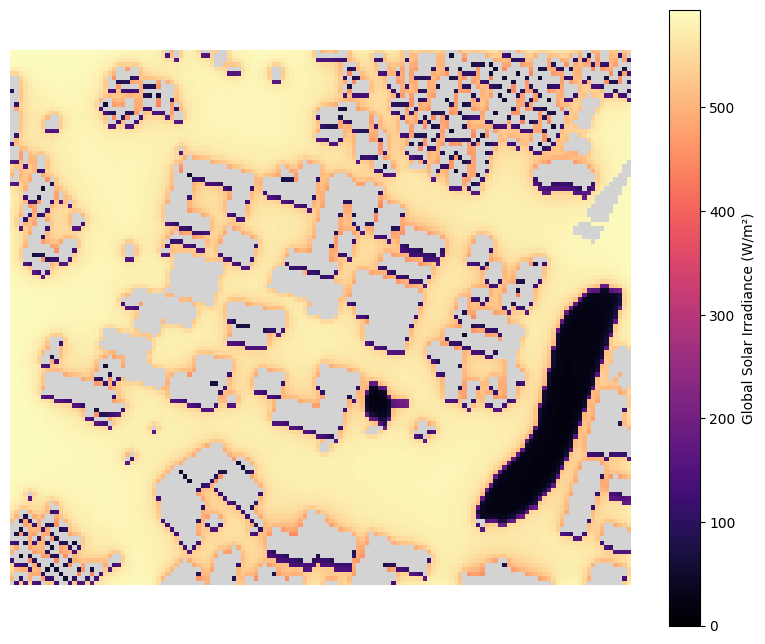

,metric,value
0,Index,Ground-level Solar Irradiance (W/m²)
1,Shape (rows × cols),121 × 140
2,Min,16.399
3,Mean,495.289
4,Median,562.271
5,Max,594.378
6,Calculation time,"June 21, 12:00"
7,Valid cells (%),74.3
8,Elapsed time (s),18.2



✅ Solar grid ready. (18.2s) Proceed to Section 2.1.2.


In [14]:
#@title 2.1.1. Solar Radiation at Ground Level
# ─────────────────────────────────────────────────────────────────
# Calculates how much solar radiation reaches the ground surface
# at a specific date and time (at pedestrian height = 1.5 m).
# The result shows which areas receive the most direct sunlight.
#
# Output unit : W/m²  (instantaneous irradiance)
# Calc time   : June 21, 12:00 (summer solstice noon — peak sun)
# EPW source  : Auto-downloaded from nearest weather station
# ─────────────────────────────────────────────────────────────────

import time

solar_grid    = None
solar_arr     = None
solar_summary = None

if RUN_SOLAR:
    if voxcity is None:
        print("❌ Voxel city model not found. Run Section 1.6 first.")
    else:
        print_stage("SOLAR RADIATION — GROUND LEVEL (2.1.1)")
        print("  Calculation type : Instantaneous")
        print("  Calculation time : June 21, 12:00 (summer solstice noon)")
        print("  Pedestrian height: 1.5 m")
        print("  EPW source       : Auto-download (nearest station)")
        print("\n  Running... this may take 1–3 minutes.\n")

        _t0 = time.time()

        # ── VoxCity API call — do not modify ──────────────────────
        try:
            solar_grid = get_global_solar_irradiance_using_epw(
                voxcity,
                calc_type="instantaneous",
                download_nearest_epw=True,
                calc_time="06-21 12:00:00",
                view_point_height=1.5,
                output_directory=None
            )
        except Exception as e:
            print(f"❌ Solar calculation failed: {e}")
            print("   → Check internet connection (EPW auto-download requires it).")
            print("   → Re-run this cell after resolving the issue.")
            solar_grid = None
        # ─────────────────────────────────────────────────────────

        _elapsed = round(time.time() - _t0, 1)

        # Guard: API may return None if EPW download fails
        if solar_grid is None:
            print("❌ Solar grid returned None.")
            print("   → Check your internet connection (EPW auto-download requires it).")
            print("   → Or provide a local EPW file via output_directory.")
        else:
            solar_arr = safe_array(solar_grid, dtype=float)

            if np.isnan(solar_arr).all():
                print("⚠️  Solar grid returned all NaN values.")
                print("   → Possible causes:")
                print("      • EPW file downloaded but contains no data for this time")
                print("      • AOI is outside the EPW station coverage area")
                print("      • voxcity object may be incomplete — re-run Section 1.6")
            else:
                _valid_pct = round(100 * np.sum(~np.isnan(solar_arr)) / solar_arr.size, 1)
                solar_summary = array_summary_df(
                    solar_arr,
                    "Ground-level Solar Irradiance (W/m²)",
                    extra_rows=[
                        {"metric": "Calculation time",  "value": "June 21, 12:00"},
                        {"metric": "Valid cells (%)",   "value": _valid_pct},
                        {"metric": "Elapsed time (s)",  "value": _elapsed},
                    ]
                )
                display(solar_summary)
                print(f"\n✅ Solar grid ready. ({_elapsed}s) Proceed to Section 2.1.2.")

else:
    print("ℹ️  Solar analysis skipped (RUN_SOLAR = False).")

In [15]:
#@title 2.1.2. Solar Radiation on Building Surfaces (Cumulative)
# ─────────────────────────────────────────────────────────────────
# Calculates total solar energy received by each building façade
# over a defined period (June 1–30 in this example).
# Useful for identifying the most sun-exposed building surfaces
# for solar panel placement or shading design.
#
# Output unit : Wh/m²  (cumulative energy over the period)
# Period      : June 1 07:00 → June 30 19:00
# EPW source  : Auto-downloaded (same station as 2.1.1)
# ─────────────────────────────────────────────────────────────────

import time

building_solar_mesh = None

if RUN_SOLAR:
    if voxcity is None:
        print("❌ Voxel city model not found. Run Section 1.6 first.")
    else:
        print_stage("SOLAR RADIATION — BUILDING SURFACES (2.1.2)")
        print("  Calculation type : Cumulative")
        print("  Period           : June 1, 07:00 → June 30, 19:00")
        print("  EPW source       : Auto-download (nearest station)")
        print("\n  ⏳ Running... cumulative mode is slower than instantaneous.")
        print("     Estimated time: 5–15 minutes depending on AOI size.\n")

        _t0 = time.time()

        # ── VoxCity API call — do not modify ──────────────────────
        building_solar_mesh = get_building_global_solar_irradiance_using_epw(
            voxcity,
            calc_type="cumulative",
            download_nearest_epw=True,
            period_start="06-01 07:00:00",
            period_end="06-30 19:00:00",
        )
        # ─────────────────────────────────────────────────────────

        _elapsed = round(time.time() - _t0, 1)

        # Guard: API may return None if EPW download or mesh fails
        if building_solar_mesh is None:
            print("❌ Building solar mesh returned None.")
            print("   → Possible causes:")
            print("      • EPW download failed (check internet connection)")
            print("      • No buildings detected in the voxel model")
            print("      • Re-run Section 1.6 to rebuild the voxel model")
        else:
            print(f"  ✅ Mesh computed in {_elapsed}s.")
            print("  Rendering 3D visualization...\n")

            # ── VoxCity visualizer — do not modify ────────────────
            try:
                visualize_voxcity(
                    voxcity,
                    mode="interactive",
                    building_sim_mesh=building_solar_mesh,
                    building_value_name="global",
                    building_colormap="magma",
                    voxel_color_map="grayscale",
                    downsample=DOWNSAMPLE_VIS
                )
            except Exception as e:
                print(f"⚠️  3D viewer failed: {e}")
                print("   → The mesh data is still valid and will be exported.")
                print("   → Check that xvfb is running (re-run Section 1.1 if needed).")
            # ─────────────────────────────────────────────────────

            print(f"\n✅ Building solar mesh ready. ({_elapsed}s) Proceed to Section 2.2.")

else:
    print("ℹ️  Building solar analysis skipped (RUN_SOLAR = False).")

Output hidden; open in https://colab.research.google.com to view.

### 2.2. Green View Index (GVI) and Sky View Index (SVI)


  GREEN VIEW INDEX + SKY VIEW INDEX (2.2.1)
  GVI : ray-casting, mode='green', height=1.5 m
  SVI : ray-casting, mode='sky',   height=1.5 m, elevation≥0°

  ⏳ Running both indices... (~2–5 minutes)



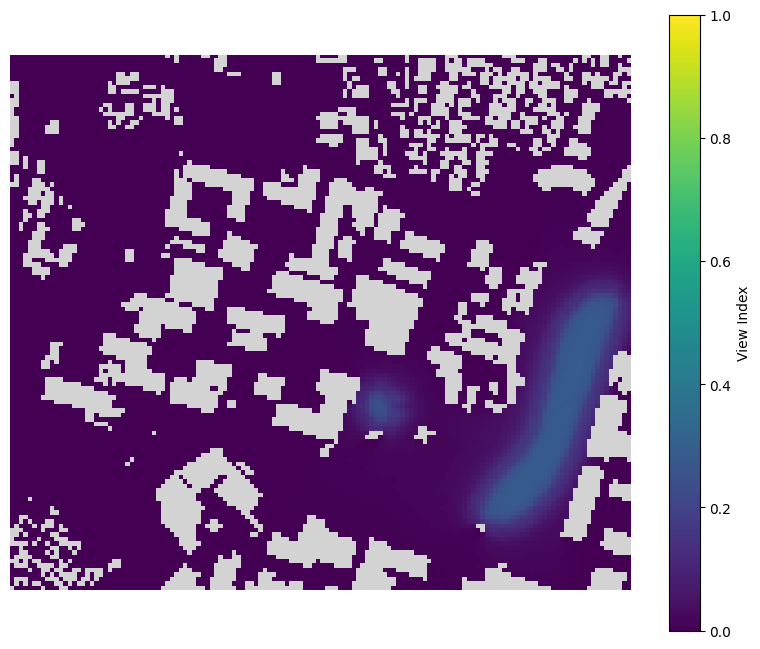

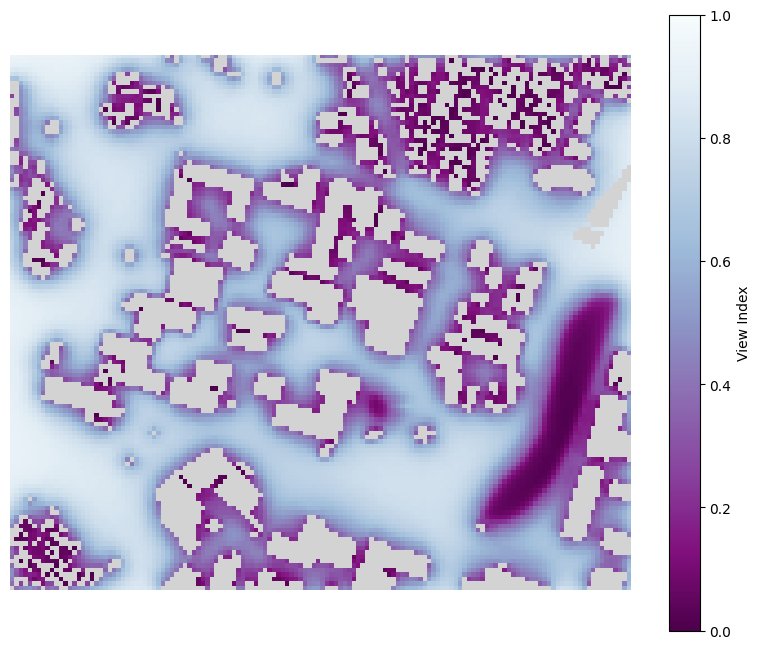

── GVI Summary ──────────────────────────────────


,metric,value
0,Index,Green View Index (GVI)
1,Shape (rows × cols),121 × 140
2,Min,0.0
3,Mean,0.021
4,Median,0.0
5,Max,0.289
6,Valid cells (%),74.3
7,Elapsed time (s),19.3


── SVI Summary ──────────────────────────────────


,metric,value
0,Index,Sky View Index (SVI)
1,Shape (rows × cols),121 × 140
2,Min,0.0
3,Mean,0.538
4,Median,0.582
5,Max,0.945
6,Valid cells (%),74.3
7,Elapsed time (s),19.3



  📊 Quick interpretation:
     Mean GVI = 0.021 (low urban greenery)
     Mean SVI = 0.538 (semi-open street geometry)

✅ GVI and SVI ready. (19.3s) Proceed to Section 2.2.2.


In [16]:
#@title 2.2.1. Ground Green View Index (GVI) and Sky View Index (SVI)
# ─────────────────────────────────────────────────────────────────
# GVI — Green View Index
#   Proportion of the hemispherical view occupied by vegetation,
#   as seen from pedestrian height (1.5 m).
#
#   GVI = N_green_voxels_visible / N_total_hemisphere_rays
#
#   Range : 0 (no greenery) → 1 (fully surrounded by vegetation)
#   Higher = more greenery visible from street level.
#
# SVI — Sky View Index
#   Proportion of the upward hemisphere that is open sky,
#   unobstructed by buildings or tree canopy.
#
#   SVI = N_unobstructed_sky_rays / N_total_rays_above_horizon
#
#   Range : 0 (fully enclosed) → 1 (fully open sky)
#   Higher = more open, less canyon-like street geometry.
#
# Both indices use ray-casting from each ground voxel centroid
# at view_point_height = 1.5 m (pedestrian eye level).
# ─────────────────────────────────────────────────────────────────

import time

gvi_grid    = gvi_arr = gvi_summary = None
svi_grid    = svi_arr = svi_summary = None

if RUN_VIEW:
    if voxcity is None:
        print("❌ Voxel city model not found. Run Section 1.6 first.")
    else:
        print_stage("GREEN VIEW INDEX + SKY VIEW INDEX (2.2.1)")
        print("  GVI : ray-casting, mode='green', height=1.5 m")
        print("  SVI : ray-casting, mode='sky',   height=1.5 m, elevation≥0°")
        print("\n  ⏳ Running both indices... (~2–5 minutes)\n")

        # ── VoxCity API calls — do not modify ─────────────────────
        _t0 = time.time()

        gvi_grid = get_view_index(
            voxcity, mode="green",
            view_point_height=1.5,
            colormap="viridis",
            output_directory=None
        )

        svi_grid = get_view_index(
            voxcity, mode="sky",
            view_point_height=1.5,
            colormap="BuPu_r",
            elevation_min_degrees=0,
            output_directory=None
        )

        _elapsed = round(time.time() - _t0, 1)
        # ─────────────────────────────────────────────────────────

        # ── GVI result handling ───────────────────────────────────
        if gvi_grid is None:
            print("❌ GVI returned None.")
            print("   → No vegetation voxels detected, or voxcity is incomplete.")
            print("   → Re-run Section 1.6 and verify land cover data.")
        else:
            gvi_arr = safe_array(gvi_grid, dtype=float)
            if np.isnan(gvi_arr).all():
                print("⚠️  GVI grid is all NaN — check voxcity land cover classes.")
            else:
                _gvi_valid_pct = round(
                    100 * np.sum(~np.isnan(gvi_arr)) / gvi_arr.size, 1
                )
                gvi_summary = array_summary_df(
                    gvi_arr, "Green View Index (GVI)",
                    extra_rows=[
                        {"metric": "Valid cells (%)", "value": _gvi_valid_pct},
                        {"metric": "Elapsed time (s)", "value": _elapsed},
                    ]
                )

        # ── SVI result handling ───────────────────────────────────
        if svi_grid is None:
            print("❌ SVI returned None.")
            print("   → Ray-casting failed — voxcity object may be incomplete.")
            print("   → Re-run Section 1.6.")
        else:
            svi_arr = safe_array(svi_grid, dtype=float)
            if np.isnan(svi_arr).all():
                print("⚠️  SVI grid is all NaN — check voxcity geometry.")
            else:
                _svi_valid_pct = round(
                    100 * np.sum(~np.isnan(svi_arr)) / svi_arr.size, 1
                )
                svi_summary = array_summary_df(
                    svi_arr, "Sky View Index (SVI)",
                    extra_rows=[
                        {"metric": "Valid cells (%)", "value": _svi_valid_pct},
                        {"metric": "Elapsed time (s)", "value": _elapsed},
                    ]
                )

        # ── Display summaries ─────────────────────────────────────
        _any_ready = False

        if gvi_summary is not None:
            print("── GVI Summary ──────────────────────────────────")
            display(gvi_summary)
            _any_ready = True

        if svi_summary is not None:
            print("── SVI Summary ──────────────────────────────────")
            display(svi_summary)
            _any_ready = True

        # ── Interpretation hint ───────────────────────────────────
        if gvi_arr is not None and svi_arr is not None:
            _mean_gvi = round(float(np.nanmean(gvi_arr)), 3)
            _mean_svi = round(float(np.nanmean(svi_arr)), 3)
            print("\n  📊 Quick interpretation:")
            print(f"     Mean GVI = {_mean_gvi:.3f} "
                  f"({'low' if _mean_gvi < 0.15 else 'moderate' if _mean_gvi < 0.35 else 'high'}"
                  f" urban greenery)")
            print(f"     Mean SVI = {_mean_svi:.3f} "
                  f"({'enclosed canyon' if _mean_svi < 0.40 else 'semi-open' if _mean_svi < 0.70 else 'open'}"
                  f" street geometry)")

        if _any_ready:
            print(f"\n✅ GVI and SVI ready. ({_elapsed}s) Proceed to Section 2.2.2.")
        else:
            print("\n⚠️  Both indices failed. Check errors above before continuing.")

else:
    print("ℹ️  View index analysis skipped (RUN_VIEW = False).")

In [17]:
#@title 2.2.2. Green View Index (GVI) on Building Surfaces
# ─────────────────────────────────────────────────────────────────
# Calculates the Surface View Factor (SVF) for vegetation as seen
# from each building façade voxel face.
#
# Formula (per building face i):
#
#   GVI_surface(i) = N_rays_hitting_green_voxels(i)
#                    ─────────────────────────────
#                    N_total_rays_cast_from_face(i)
#
#   Range : 0 (no greenery visible) → 1 (fully surrounded by green)
#
# Target voxel codes counted as "green" (inclusion_mode=True):
#   -2 → Tree canopy       5 → Tree (ground class)
#    2 → Rangeland          6 → Moss / lichen
#    3 → Shrub              7 → Wetland
#    4 → Agriculture        8 → Mangrove
#
# Visualizer note:
#   building_vmax=0.2 — in dense urban areas, a façade with 20%
#   green view is already high. Values above 0.2 are clipped to
#   the top color of the colormap (not discarded).
# ─────────────────────────────────────────────────────────────────

import time

building_gvi_mesh = None

if RUN_VIEW:
    if voxcity is None:
        print("❌ Voxel city model not found. Run Section 1.6 first.")
    else:
        print_stage("GVI — BUILDING SURFACES (2.2.2)")
        print("  Method  : Surface view factor via ray-casting")
        print("  Targets : Tree canopy + all vegetation land-cover classes")
        print("  Mode    : inclusion_mode=True (green voxels counted)")
        print("\n  ⏳ Running... progress reported below.\n")

        _t0 = time.time()

        # ── VoxCity API call — do not modify ──────────────────────
        building_gvi_mesh = get_surface_view_factor(
            voxcity,
            target_values=(-2, 2, 3, 4, 5, 6, 7, 8),
            inclusion_mode=True,
            progress_report=True
        )
        # ─────────────────────────────────────────────────────────

        _elapsed = round(time.time() - _t0, 1)

        if building_gvi_mesh is None:
            print("❌ Building GVI mesh returned None.")
            print("   → Possible causes:")
            print("      • No building voxels detected in the model")
            print("      • No vegetation voxels present in the AOI")
            print("      • Re-run Section 1.6 and verify land cover data")
        else:
            print(f"\n  ✅ Mesh computed in {_elapsed}s.")

            # Quick mesh statistics (view_factor_values key)
            try:
                _vf_vals = np.array(building_gvi_mesh["view_factor_values"],
                                    dtype=float)
                _vf_vals_valid = _vf_vals[~np.isnan(_vf_vals)]
                if len(_vf_vals_valid) > 0:
                    print(f"\n  📊 Surface GVI statistics:")
                    print(f"     Faces computed : {len(_vf_vals_valid):,}")
                    print(f"     Mean GVI       : {np.mean(_vf_vals_valid):.3f}")
                    print(f"     Median GVI     : {np.median(_vf_vals_valid):.3f}")
                    print(f"     Max GVI        : {np.max(_vf_vals_valid):.3f}")
                    print(f"     Faces > 0.20   : "
                          f"{np.sum(_vf_vals_valid > 0.20):,} "
                          f"({100*np.mean(_vf_vals_valid > 0.20):.1f}% — high green view)")
            except (KeyError, TypeError):
                # Mesh structure may vary — skip stats silently
                pass

            print("\n  Rendering 3D visualization...\n")

            # ── VoxCity visualizer — do not modify ────────────────
            try:
                visualize_voxcity(
                    voxcity,
                    building_sim_mesh=building_gvi_mesh,
                    building_value_name="view_factor_values",
                    building_colormap="viridis",
                    building_opacity=1.0,
                    building_vmin=0.0,
                    building_vmax=0.2,
                    render_voxel_buildings=False,
                    voxel_color_map="grayscale",
                    downsample=DOWNSAMPLE_VIS
                )
            except Exception as e:
                print(f"⚠️  3D viewer failed: {e}")
                print("   → Mesh data is still valid and will be exported.")
                print("   → Check that xvfb is running (re-run Section 1.1 if needed).")
            # ─────────────────────────────────────────────────────

            print(f"\n✅ Building GVI mesh ready. ({_elapsed}s) Proceed to Section 2.3.")

else:
    print("ℹ️  Building GVI skipped (RUN_VIEW = False).")

Output hidden; open in https://colab.research.google.com to view.

### 2.3. Network (Walkability) and Space Syntax Analysis

In [18]:
#@title 2.3.1. Download Pedestrian Network and OSM Features
# ─────────────────────────────────────────────────────────────────
# Downloads the pedestrian street network and spatial features
# from OpenStreetMap within the AOI. This data feeds three
# downstream analyses:
#
#   • Walkability Index    (Section 2.3.2)
#   • Street Integration   (Section 2.3.3)
#   • Wind Corridor        (Section 2.4)
#
# Graph structure:
#   G = (V, E)
#   V = street intersections (nodes)
#   E = street segments (edges, with length in metres)
#
#   Mean node degree:
#   d̄ = (1/|V|) × Σ deg(v)   for all v ∈ V
#
#   Interpretation:
#   d̄ ≈ 2.0  → mostly dead-ends / linear streets
#   d̄ ≈ 3.0  → typical urban grid with T-intersections
#   d̄ ≥ 4.0  → dense grid, many 4-way intersections
#
# Proximity distances (used in 2.3.2):
#   d_amenity(v) = min over a in A of ||p_v - p_a||
#   Requires metric CRS (EPSG:3857) for distances in metres.
#
# Built obstruction (used in 2.4):
#   Buffer each edge by ROAD_BUFFER_M metres, intersect with
#   buildings_osm to compute obstruction ratio per street.
# ─────────────────────────────────────────────────────────────────

import time

walk_G          = None
walk_nodes      = None
walk_edges      = None
walk_nodes_proj = None
walk_edges_proj = None
amenities       = None
green_areas     = None
buildings_osm   = None

if RUN_WALKABILITY or RUN_INTEGRATION or RUN_WIND_SCREENING:
    if "aoi_polygon" not in globals() or aoi_polygon is None:
        print("❌ AOI not defined. Run Section 1.5 first.")
    else:
        print_stage("DOWNLOADING OSM NETWORK AND FEATURES (2.3.1)")
        _t0 = time.time()

        # ── Step 1: Pedestrian street network ─────────────────────
        print("  ⬇️  Fetching pedestrian network from OSM...")
        try:
            walk_G = ox.graph_from_polygon(
                aoi_polygon, network_type="walk", simplify=True
            )

            walk_nodes, walk_edges = ox.graph_to_gdfs(
                walk_G, nodes=True, edges=True
            )

            # OSMnx returns EPSG:4326 — use to_crs(), not set_crs()
            # set_crs(allow_override=True) would silently mislabel
            # the CRS if it were ever different, corrupting distances.
            walk_nodes = walk_nodes.to_crs(4326)
            walk_edges = walk_edges.to_crs(4326)

            # Projected CRS (EPSG:3857, metres) for distance calculations
            walk_nodes_proj = walk_nodes.to_crs(3857)
            walk_edges_proj = walk_edges.to_crs(3857)

            print(f"  ✅ Network downloaded.")

        except Exception as e:
            print(f"  ❌ Network download failed: {e}")
            print("     → Check internet connection and AOI validity.")
            print("     → AOI may be too small or in an area with no OSM data.")

        # ── Step 2: OSM feature layers ────────────────────────────
        # Each layer is used by a specific downstream analysis:
        #   amenities    → walkability proximity score
        #   green_areas  → walkability green access + map background
        #   buildings_osm → wind corridor obstruction ratio

        print("\n  ⬇️  Fetching OSM feature layers...")

        amenities = safe_features_from_polygon(
            aoi_polygon,
            {"amenity": True, "shop": True, "public_transport": True}
        )

        green_areas = safe_features_from_polygon(
            aoi_polygon,
            {
                "leisure": ["park", "garden"],
                "landuse": ["grass", "recreation_ground"],
                "natural": ["wood"]
            }
        )

        buildings_osm = safe_features_from_polygon(
            aoi_polygon,
            {"building": True}
        )

        _elapsed = round(time.time() - _t0, 1)

        # ── Step 3: Summary ───────────────────────────────────────
        if walk_G is not None:
            net_stats = summarize_graph(walk_G)

            print(f"\n{'─' * 50}")
            print(f"  Network nodes        : {net_stats['nodes']}")
            print(f"  Network edges        : {net_stats['edges']}")
            print(f"  Avg node degree (d̄) : {net_stats['avg_degree']}"
                  f"  ({'dense grid' if net_stats['avg_degree'] >= 3.5 else 'typical urban' if net_stats['avg_degree'] >= 2.5 else 'sparse / linear'})")
            print(f"  Total network length : {net_stats.get('total_length_km', 'n/a')} km")
            print(f"{'─' * 50}")
            print(f"  Amenities found      : {len(amenities)}"
                  f"{'  ⚠️  (low — may reduce walkability score accuracy)' if len(amenities) < 10 else ''}")
            print(f"  Green features       : {len(green_areas)}"
                  f"{'  ⚠️  (none found — green access score will use max distance cap)' if len(green_areas) == 0 else ''}")
            print(f"  Buildings (OSM)      : {len(buildings_osm)}"
                  f"{'  ⚠️  (none — wind obstruction ratio will be 0)' if len(buildings_osm) == 0 else ''}")
            print(f"{'─' * 50}")
            print(f"\n✅ OSM data ready. ({_elapsed}s) Proceed to Section 2.3.2.")
        else:
            print("\n⚠️  Network unavailable — dependent analyses will be skipped.")

else:
    print("ℹ️  OSM download skipped (Walkability, Integration, and Wind are all disabled).")


  DOWNLOADING OSM NETWORK AND FEATURES (2.3.1)
  ⬇️  Fetching pedestrian network from OSM...
  ✅ Network downloaded.

  ⬇️  Fetching OSM feature layers...

──────────────────────────────────────────────────
  Network nodes        : 127
  Network edges        : 153
  Avg node degree (d̄) : 2.409  (sparse / linear)
  Total network length : 6.936 km
──────────────────────────────────────────────────
  Amenities found      : 43
  Green features       : 13
  Buildings (OSM)      : 405
──────────────────────────────────────────────────

✅ OSM data ready. (13.9s) Proceed to Section 2.3.2.


In [19]:
#@title 2.3.2. Walkability Index
# ─────────────────────────────────────────────────────────────────
# Scores each street segment for walkability using a weighted
# composite of five normalized sub-scores.
#
# Composite formula:
#   W(e) = 0.25·C(e) + 0.25·L(e) + 0.25·A(e) + 0.15·G(e) + 0.10·I(e)
#
# All components ∈ [0, 1] via min-max normalization:
#
#   C(e) — Network connectivity (25%)
#     Normalized node degree, averaged across edge endpoints:
#     C(e) = ( norm(deg_u) + norm(deg_v) ) / 2
#
#   L(e) — Segment length score (25%)
#     Shorter = more walkable (inverted normalization):
#     L(e) = 1 - norm(length_m)
#
#   A(e) — Amenity proximity (25%)
#     Closer to shops/services/transit = better:
#     A(e) = ( (1 - norm(d_amenity_u)) + (1 - norm(d_amenity_v)) ) / 2
#     Fallback: if no amenities exist → A(e) = 0 (worst, not best)
#
#   G(e) — Green area proximity (15%)
#     Closer to parks/gardens = better:
#     G(e) = ( (1 - norm(d_green_u)) + (1 - norm(d_green_v)) ) / 2
#     Fallback: if no green areas exist → G(e) = 0
#
#   I(e) — Intersection presence (10%)
#     Whether endpoints are intersections (degree ≥ 3),
#     min-max normalized to [0, 1]:
#     I(e) = ( norm(flag_u) + norm(flag_v) ) / 2
#
# Score range: 0 (very low walkability) → 1 (very high walkability)
# ─────────────────────────────────────────────────────────────────

import time

walkability_edges   = None
walkability_summary = None
walkability_map     = None

if RUN_WALKABILITY and walk_G is not None:
    print_stage("WALKABILITY INDEX (2.3.2)")
    _t0 = time.time()

    # ── Step 1: Graph simplification and node degree ──────────────
    G_simple   = nx.Graph(ox.convert.to_undirected(walk_G))
    node_degree = pd.Series(dict(G_simple.degree()), name="degree")

    nodes = walk_nodes_proj.copy()
    nodes = nodes[nodes.geometry.notna()].copy()
    nodes["node_id"] = nodes.index
    nodes["degree"]  = nodes["node_id"].map(node_degree).fillna(0).astype(float)

    # intersection_flag: 1 if degree ≥ 3, else 0
    # min-max normalized so it sits on [0,1] like all other components.
    # Raw binary {0,1} would compress the 10% weight to {0, 0.5, 1}
    # after edge-averaging — normalization fixes this.
    nodes["intersection_flag"] = (nodes["degree"] >= 3).astype(float)
    _flag_min = nodes["intersection_flag"].min()
    _flag_max = nodes["intersection_flag"].max()
    if _flag_max > _flag_min:
        nodes["intersection_flag_norm"] = (
            (nodes["intersection_flag"] - _flag_min) / (_flag_max - _flag_min)
        )
    else:
        # All nodes same flag value — uniform score of 0.5
        nodes["intersection_flag_norm"] = 0.5

    area_km2 = polygon_area_km2(aoi_polygon)

    # ── Step 2: Edge geometry and length ─────────────────────────
    edges = walk_edges_proj.reset_index().copy()
    edges = edges[edges.geometry.notna()].copy()
    edges["length_m"] = edges.geometry.length.astype(float)

    # ── Step 3: Proximity distances ───────────────────────────────
    # Fallback cap: if no features exist, fill with a large distance
    # so access score → 0 (worst), not 1 (best).
    # Using 5000 m as the cap (beyond which access is negligible).
    _DIST_CAP = 5000.0

    amenity_dist = nearest_distance_clean(
        nodes,
        amenities.to_crs(3857)
        if amenities is not None and not amenities.empty else None
    )
    green_dist = nearest_distance_clean(
        nodes,
        green_areas.to_crs(3857)
        if green_areas is not None and not green_areas.empty else None
    )

    # Fill NaN: use observed max if available, else cap distance
    _amenity_fill = (amenity_dist.max()
                     if amenity_dist.notna().any() else _DIST_CAP)
    _green_fill   = (green_dist.max()
                     if green_dist.notna().any() else _DIST_CAP)

    amenity_dist_filled = amenity_dist.fillna(_amenity_fill)
    green_dist_filled   = green_dist.fillna(_green_fill)

    # Warn if fallback was triggered — affects score interpretation
    if not amenity_dist.notna().any():
        print("  ⚠️  No amenities found — amenity access score set to 0 for all nodes.")
    if not green_dist.notna().any():
        print("  ⚠️  No green areas found — green access score set to 0 for all nodes.")

    # ── Step 4: Node-level scores (all ∈ [0, 1]) ─────────────────
    nodes["amenity_access"] = (
        1 - minmax_norm(amenity_dist_filled)
    ).to_numpy()
    nodes["green_access"]   = (
        1 - minmax_norm(green_dist_filled)
    ).to_numpy()
    nodes["connectivity"]   = minmax_norm(
        nodes["degree"]
    ).fillna(0).to_numpy()

    node_scores = nodes.set_index("node_id")[[
        "connectivity", "amenity_access",
        "green_access", "intersection_flag_norm"
    ]]

    # ── Step 5: Edge-level scores (average of two endpoints) ─────
    def edge_avg(col):
        u_vals = node_scores[col].reindex(edges["u"]).fillna(0).to_numpy()
        v_vals = node_scores[col].reindex(edges["v"]).fillna(0).to_numpy()
        return (u_vals + v_vals) / 2.0

    edges["connectivity_score"] = edge_avg("connectivity")
    edges["amenity_access"]     = edge_avg("amenity_access")
    edges["green_access"]       = edge_avg("green_access")
    edges["intersection_score"] = edge_avg("intersection_flag_norm")
    edges["segment_score"]      = (
        1 - minmax_norm(edges["length_m"]).fillna(0)
    ).to_numpy()

    # ── Step 6: Composite walkability index ──────────────────────
    # W(e) = 0.25·C + 0.25·L + 0.25·A + 0.15·G + 0.10·I
    # Weights sum to 1.0 — verified below.
    _WEIGHTS = {
        "connectivity_score": 0.25,
        "segment_score":      0.25,
        "amenity_access":     0.25,
        "green_access":       0.15,
        "intersection_score": 0.10,
    }
    assert abs(sum(_WEIGHTS.values()) - 1.0) < 1e-9, \
        f"Weights must sum to 1.0, got {sum(_WEIGHTS.values())}"

    edges["walkability_index"] = sum(
        w * edges[col] for col, w in _WEIGHTS.items()
    )

    edges["walkability_class"] = pd.cut(
        edges["walkability_index"],
        bins=[-0.01, 0.20, 0.40, 0.60, 0.80, 1.00],
        labels=["Very Low", "Low", "Moderate", "High", "Very High"]
    )

    walkability_edges = edges

    # ── Step 7: Summary table ─────────────────────────────────────
    _elapsed = round(time.time() - _t0, 1)
    _mean_wi = float(edges["walkability_index"].mean())

    walkability_summary = pd.DataFrame([
        {"metric": "Area (km²)",
         "value": round(area_km2, 3)},
        {"metric": "Street segments",
         "value": len(edges)},
        {"metric": "Intersection density / km²",
         "value": round(
             nodes["intersection_flag"].sum() / max(area_km2, 1e-6), 2
         )},
        {"metric": "Mean walkability index",
         "value": round(_mean_wi, 3)},
        {"metric": "Median walkability index",
         "value": round(float(edges["walkability_index"].median()), 3)},
        {"metric": "Max walkability index",
         "value": round(float(edges["walkability_index"].max()), 3)},
        {"metric": "High + Very High segments (%)",
         "value": round(
             100 * edges["walkability_class"]
             .isin(["High", "Very High"]).mean(), 1
         )},
        {"metric": "Elapsed time (s)",
         "value": _elapsed},
    ])
    display(walkability_summary)

    # Interpretation hint
    print(f"\n  📊 Mean walkability = {_mean_wi:.3f} — "
          f"{'very low' if _mean_wi < 0.20 else 'low' if _mean_wi < 0.40 else 'moderate' if _mean_wi < 0.60 else 'high' if _mean_wi < 0.80 else 'very high'}"
          f" overall walkability for this AOI.")

    # ── Step 8: Map ───────────────────────────────────────────────
    amenities_pts = None
    if amenities is not None and not amenities.empty:
        amenities_pts = amenities[amenities.geometry.notna()].copy().to_crs(3857)
        amenities_pts["geometry"] = amenities_pts.geometry.centroid

    walkability_map = make_line_map(
        lines_gdf=walkability_edges,
        value_col="walkability_index",
        aoi_gdf=aoi_gdf,
        green_areas=green_areas,
        caption="Walkability Index",
        overlay_name="Walkability Index",
        tooltip_fields=[
            "walkability_index", "walkability_class",
            "connectivity_score", "amenity_access", "segment_score"
        ],
        tooltip_aliases=[
            "Walkability Index", "Class",
            "Connectivity", "Amenity Access", "Segment Score"
        ],
        point_gdf=amenities_pts,
        point_name="Amenities",
        point_color="orange"
    )
    display(walkability_map)
    print(f"\n✅ Walkability index ready. ({_elapsed}s) Proceed to Section 2.3.3.")

else:
    print("ℹ️  Walkability skipped (RUN_WALKABILITY = False or network unavailable).")


  WALKABILITY INDEX (2.3.2)


,metric,value
0,Area (km²),0.422
1,Street segments,306.000
2,Intersection density / km²,177.920
3,Mean walkability index,0.717
4,Median walkability index,0.729
5,Max walkability index,0.975
6,High + Very High segments (%),82.400
7,Elapsed time (s),0.200



  📊 Mean walkability = 0.717 — high overall walkability for this AOI.



✅ Walkability index ready. (0.2s) Proceed to Section 2.3.3.


In [21]:
#@title 2.3.3. Street Integration Mobility Index (Space Syntax)
# ─────────────────────────────────────────────────────────────────
# Estimates how central and strategic each street segment is in
# the pedestrian movement network, using two graph-theory measures
# adapted from Space Syntax theory (Hillier & Hanson, 1984).
#
# NOTE: This is a metric-graph approximation of Space Syntax.
# True Space Syntax uses angular segment analysis; here we use
# shortest-path distances on a projected graph (EPSG:3857, metres).
#
# ── Closeness Centrality (Integration proxy, 60%) ────────────────
#   How easily a node reaches all others via shortest paths.
#   NetworkX normalized formula (handles disconnected components):
#
#         |V_r| - 1     |V_r| - 1
#   C_C = ───────────  ×  ──────────────────
#         |V| - 1       Σ d(v, u), u ≠ v
#
#   |V_r| = reachable nodes from v (< |V| in disconnected graphs).
#   Higher C_C → node is closer to all others → high integration.
#   NetworkX param: distance="length" (treats length as path cost).
#
# ── Betweenness Centrality (Choice proxy, 40%) ───────────────────
#   How often a node lies on shortest paths between other pairs:
#
#              1              σ_st(v)
#   C_B(v) = ────────────── × Σ ───────
#            (|V|-1)(|V|-2)   σ_st
#
#   σ_st     = total shortest paths from s to t
#   σ_st(v)  = those paths passing through v
#   Higher C_B → node is a movement corridor → high choice.
#   NetworkX param: weight="length", normalized=True.
#
# ── Composite Street Mobility Index ──────────────────────────────
#   Both scores min-max normalized, then combined at edge level:
#
#   M(e) = 0.60 · norm(C_C)(e) + 0.40 · norm(C_B)(e)
#
#   Edge score = mean of the two endpoint node scores.
#   Score range: 0 (very low mobility) → 1 (very high mobility)
# ─────────────────────────────────────────────────────────────────

import time

integration_edges   = None
integration_summary = None
integration_map     = None

# Betweenness approximation threshold:
# For |V| > _BW_EXACT_LIMIT, use k random pivots to keep runtime
# under ~2 minutes. k=500 gives <5% error on typical urban graphs.
_BW_EXACT_LIMIT = 2000
_BW_K_APPROX    = 500

if RUN_INTEGRATION and walk_G is not None:
    print_stage("STREET INTEGRATION MOBILITY INDEX (2.3.3)")
    _t0 = time.time()

    # ── Step 1: Graph preparation ─────────────────────────────────
    G_simple  = nx.Graph(ox.convert.to_undirected(walk_G))
    int_nodes = walk_nodes_proj[walk_nodes_proj.geometry.notna()].copy()
    int_nodes["node_id"] = int_nodes.index
    int_edges = walk_edges_proj.reset_index().copy()
    int_edges = int_edges[int_edges.geometry.notna()].copy()
    int_edges["length_m"] = int_edges.geometry.length.astype(float)

    _n_nodes = G_simple.number_of_nodes()
    _n_edges = G_simple.number_of_edges()
    print(f"  Graph: {_n_nodes} nodes, {_n_edges} edges")

    # ── Step 2: Edge length assignment ────────────────────────────
    # nx.Graph(multigraph) keeps one edge per pair arbitrarily.
    # Guard: replace zero or missing lengths with Euclidean fallback
    # (computed in EPSG:3857 → metres, consistent with node geometry).
    _fixed = 0
    for u, v, data in G_simple.edges(data=True):
        if data.get("length", 0) <= 0:
            try:
                pu = int_nodes.loc[u].squeeze().geometry
                pv = int_nodes.loc[v].squeeze().geometry
                data["length"] = pu.distance(pv)
            except Exception:
                data["length"] = 1.0
            _fixed += 1
    if _fixed > 0:
        print(f"  ⚠️  {_fixed} edges had zero/missing length — Euclidean fallback applied.")

    # ── Step 3: Closeness centrality (integration) ────────────────
    # distance="length": higher length = farther = lower centrality.
    # NetworkX applies the normalized formula automatically,
    # which correctly handles disconnected graph components.
    print(f"  Computing closeness centrality ({_n_nodes} nodes)...")
    _t1 = time.time()
    try:
        closeness = pd.Series(
            nx.closeness_centrality(G_simple, distance="length")
        )
        print(f"  ✅ Closeness done ({round(time.time()-_t1, 1)}s)")
    except Exception as e:
        print(f"  ❌ Closeness centrality failed: {e}")
        print("     → Check graph connectivity and edge lengths.")
        raise

    # ── Step 4: Betweenness centrality (choice) ───────────────────
    # weight="length": higher length = costlier path (same metric).
    # normalized=True → divided by (|V|-1)(|V|-2) → range [0, 1].
    # For large graphs, use k-approximation to bound runtime.
    _use_approx = _n_nodes > _BW_EXACT_LIMIT
    _bw_k       = _BW_K_APPROX if _use_approx else None

    if _use_approx:
        print(f"  Computing betweenness centrality "
              f"(approximation, k={_bw_k} — graph has {_n_nodes} nodes > {_BW_EXACT_LIMIT})...")
    else:
        print(f"  Computing betweenness centrality (exact, {_n_nodes} nodes)...")

    _t2 = time.time()
    try:
        betweenness = pd.Series(
            nx.betweenness_centrality(
                G_simple, weight="length",
                normalized=True,
                k=_bw_k
            )
        )
        print(f"  ✅ Betweenness done ({round(time.time()-_t2, 1)}s)"
              f"{'  [approximation]' if _use_approx else ''}")
    except Exception as e:
        print(f"  ❌ Betweenness centrality failed: {e}")
        print("     → Check graph connectivity and edge lengths.")
        raise

    # ── Step 5: Node-level scores (min-max normalized) ────────────
    int_nodes["integration_score"] = minmax_norm(
        closeness.reindex(int_nodes["node_id"]).fillna(0)
    ).to_numpy()
    int_nodes["choice_score"] = minmax_norm(
        betweenness.reindex(int_nodes["node_id"]).fillna(0)
    ).to_numpy()

    node_scores = int_nodes.set_index("node_id")[
        ["integration_score", "choice_score"]
    ]

    # ── Step 6: Edge-level scores (mean of two endpoints) ─────────
    def edge_avg_int(col):
        u_vals = node_scores[col].reindex(int_edges["u"]).fillna(0).to_numpy()
        v_vals = node_scores[col].reindex(int_edges["v"]).fillna(0).to_numpy()
        return (u_vals + v_vals) / 2.0

    int_edges["integration_score"] = edge_avg_int("integration_score")
    int_edges["choice_score"]      = edge_avg_int("choice_score")

    # ── Step 7: Composite index ───────────────────────────────────
    # M(e) = 0.60 · norm(C_C)(e) + 0.40 · norm(C_B)(e)
    # Weights verified: 0.60 + 0.40 = 1.0
    _WEIGHTS = {"integration_score": 0.60, "choice_score": 0.40}
    assert abs(sum(_WEIGHTS.values()) - 1.0) < 1e-9, \
        f"Weights must sum to 1.0, got {sum(_WEIGHTS.values())}"

    int_edges["street_mobility_index"] = sum(
        w * int_edges[col] for col, w in _WEIGHTS.items()
    )
    int_edges["mobility_class"] = pd.cut(
        int_edges["street_mobility_index"],
        bins=[-0.01, 0.20, 0.40, 0.60, 0.80, 1.00],
        labels=["Very Low", "Low", "Moderate", "High", "Very High"]
    )

    integration_edges = int_edges
    _elapsed = round(time.time() - _t0, 1)

    # ── Step 8: Summary table ─────────────────────────────────────
    _mean_mi = float(int_edges["street_mobility_index"].mean())

    integration_summary = pd.DataFrame([
        {"metric": "Street segments",
         "value": len(int_edges)},
        {"metric": "Graph nodes",
         "value": _n_nodes},
        {"metric": "Betweenness method",
         "value": f"Approximation (k={_bw_k})" if _use_approx else "Exact"},
        {"metric": "Mean integration score (C_C)",
         "value": round(float(int_edges["integration_score"].mean()), 3)},
        {"metric": "Mean choice score (C_B)",
         "value": round(float(int_edges["choice_score"].mean()), 3)},
        {"metric": "Mean street mobility index",
         "value": round(_mean_mi, 3)},
        {"metric": "Max street mobility index",
         "value": round(float(int_edges["street_mobility_index"].max()), 3)},
        {"metric": "High + Very High segments (%)",
         "value": round(
             100 * int_edges["mobility_class"]
             .isin(["High", "Very High"]).mean(), 1
         )},
        {"metric": "Elapsed time (s)",
         "value": _elapsed},
    ])
    display(integration_summary)

    print(f"\n  📊 Mean mobility index = {_mean_mi:.3f} — "
          f"{'very low' if _mean_mi < 0.20 else 'low' if _mean_mi < 0.40 else 'moderate' if _mean_mi < 0.60 else 'high' if _mean_mi < 0.80 else 'very high'}"
          f" street integration for this AOI.")

    # ── Step 9: Map ───────────────────────────────────────────────
    # Top nodes ranked by composite index for visual consistency
    # with the line color scale (street_mobility_index).
    top_nodes = int_nodes.nlargest(
        min(200, len(int_nodes)), "integration_score"
    ).copy()
    top_nodes["street_mobility_index"] = (
        0.60 * top_nodes["integration_score"] +
        0.40 * top_nodes["choice_score"]
    )
    top_nodes = top_nodes.nlargest(
        min(200, len(top_nodes)), "street_mobility_index"
    ).copy()

    integration_map = make_line_map(
        lines_gdf=integration_edges,
        value_col="street_mobility_index",
        aoi_gdf=aoi_gdf,
        green_areas=green_areas,
        caption="Street Mobility Index",
        overlay_name="Street Integration Mobility",
        tooltip_fields=[
            "street_mobility_index", "mobility_class",
            "integration_score", "choice_score", "length_m"
        ],
        tooltip_aliases=[
            "Street Mobility Index", "Class",
            "Integration Score", "Choice Score", "Length (m)"
        ],
        point_gdf=top_nodes,
        point_name="Top Integration Nodes",
        point_color="#d7301f",
        point_radius=3,
        top_lines_gdf=None
    )
    display(integration_map)
    print(f"\n✅ Street integration mobility index ready. ({_elapsed}s) Proceed to Section 2.4.")

else:
    print("ℹ️  Street integration skipped "
          "(RUN_INTEGRATION = False or network unavailable).")


  STREET INTEGRATION MOBILITY INDEX (2.3.3)
  Graph: 127 nodes, 151 edges
  Computing closeness centrality (127 nodes)...
  ✅ Closeness done (0.1s)
  Computing betweenness centrality (exact, 127 nodes)...
  ✅ Betweenness done (0.2s)


,metric,value
0,Street segments,306
1,Graph nodes,127
2,Betweenness method,Exact
3,Mean integration score (C_C),0.501
4,Mean choice score (C_B),0.278
5,Mean street mobility index,0.412
6,Max street mobility index,0.993
7,High + Very High segments (%),24.2
8,Elapsed time (s),0.4



  📊 Mean mobility index = 0.412 — moderate street integration for this AOI.



✅ Street integration mobility index ready. (0.4s) Proceed to Section 2.4.


### 2.4. Wind Corridor Analysis

In [23]:
#@title 2.4.1. Wind Corridor Screening Index
# ─────────────────────────────────────────────────────────────────
# Lightweight screening tool — NOT a full CFD simulation.
# Estimates natural ventilation potential per street segment
# using two normalized sub-scores:
#
# ── Wind Alignment Score (60%) ────────────────────────────────────
#   Bidirectional angular alignment between street bearing θ_e
#   and prevailing wind direction φ, folded to [0°, 90°]:
#
#   fold(x) = min(|x| mod 360, 360 − |x| mod 360)
#
#   diff_fwd = fold(θ_e − φ)
#   diff_rev = fold(θ_e − (φ + 180°))
#   min_diff = min(diff_fwd, diff_rev)   ∈ [0°, 90°]
#
#   α(e) = 1 − (min_diff / 90)          ∈ [0, 1]
#
#   Then min-max normalized for consistent [0,1] scaling:
#   α̂(e) = (α(e) − min α) / (max α − min α)
#
# ── Openness Score (40%) ─────────────────────────────────────────
#   Fraction of the road buffer NOT covered by buildings.
#   Spatial index (sindex) used for efficient candidate filtering:
#
#   R_built(e) = Area(buildings ∩ buffer(e, r)) / Area(buffer(e, r))
#
#   Ô(e) = 1 − norm(R_built(e))
#
# ── Composite Index ───────────────────────────────────────────────
#   W(e) = 0.60 · α̂(e) + 0.40 · Ô(e)
#
#   Both components normalized to [0,1] before weighting.
#
# NOTE: Street bearings are computed on EPSG:3857 (Mercator).
#   Error is negligible near the equator (<1° at ±10° latitude)
#   but increases at higher latitudes. For high-latitude cities,
#   compute bearings on unprojected edges (EPSG:4326) instead.
#
# Score range: 0 (very low ventilation potential)
#           → 1 (very high ventilation potential)
# Set PREVAILING_WIND_DEG in Section 1.4 to match your study area.
# ─────────────────────────────────────────────────────────────────

import time

wind_edges   = None
wind_summary = None
wind_map     = None

# Conservative NaN fill for obstruction ratio:
# unknown obstruction → assume fully obstructed (worst case = 1.0)
_OBS_NAN_FILL = 1.0

if RUN_WIND_SCREENING and walk_edges_proj is not None:
    print_stage("WIND CORRIDOR SCREENING INDEX (2.4)")
    print(f"  Prevailing wind direction : {PREVAILING_WIND_DEG}°")
    print(f"  Road buffer radius        : {ROAD_BUFFER_M} m")
    _t0 = time.time()

    try:
        # ── Step 1: Edge geometry and bearing ────────────────────
        edges = walk_edges_proj.reset_index().copy()
        edges = edges[edges.geometry.notna()].copy()
        edges["length_m"]    = edges.geometry.length.astype(float)
        edges["bearing_deg"] = edges.geometry.apply(edge_bearing)

        # Report NaN bearings (zero-length segments)
        _bearing_nan = edges["bearing_deg"].isna().sum()
        if _bearing_nan > 0:
            print(f"  ⚠️  {_bearing_nan} edges had no valid bearing "
                  f"(zero-length) — wind alignment set to 0.")

        # Raw angular alignment ∈ [0, 1] via bidirectional fold
        # (handles 0°/360° wrap boundary correctly)
        edges["wind_alignment"] = edges["bearing_deg"].apply(
            lambda x: angular_alignment(x, PREVAILING_WIND_DEG)
        )

        # Min-max normalize so alignment spans full [0,1] range —
        # consistent with open_score scaling for correct 60/40 split.
        edges["wind_alignment_score"] = minmax_norm(
            pd.Series(edges["wind_alignment"]).fillna(0).astype(float)
        ).fillna(0).to_numpy()

        # ── Step 2: Built obstruction ratio ──────────────────────
        # Uses spatial index (sindex) to pre-filter candidate
        # buildings per buffer — avoids O(n×m) full scan.
        if buildings_osm is not None and not buildings_osm.empty:
            print(f"\n  Calculating built obstruction ratio "
                  f"({len(edges)} segments × buffer {ROAD_BUFFER_M} m)...")
            bld   = buildings_osm[buildings_osm.geometry.notna()].copy().to_crs(3857)
            bld_sindex = bld.sindex
            built_ratio = []
            _n = len(edges)

            for _i, geom in enumerate(edges.geometry.buffer(ROAD_BUFFER_M)):
                if _i % 50 == 0:
                    print(f"    {_i}/{_n} segments processed...", end="\r")
                try:
                    # Spatial index candidate filter — fast bbox pre-screen
                    candidates = list(bld_sindex.intersection(geom.bounds))
                    if not candidates:
                        built_ratio.append(0.0)
                        continue
                    local_bld  = bld.iloc[candidates]
                    inter      = local_bld[local_bld.intersects(geom)].copy()
                    inter.geometry = inter.geometry.intersection(geom)
                    built_area = inter.area.sum() if len(inter) > 0 else 0.0
                    built_ratio.append(
                        built_area / geom.area if geom.area > 0 else np.nan
                    )
                except Exception:
                    built_ratio.append(np.nan)

            print(f"    {_n}/{_n} segments processed.   ")
            edges["built_obstruction_ratio"] = built_ratio

            _nan_count = pd.Series(built_ratio).isna().sum()
            if _nan_count > 0:
                print(f"  ⚠️  {_nan_count} segments had no valid buffer geometry "
                      f"— filled with obstruction = {_OBS_NAN_FILL} (worst case).")
        else:
            print("  ⚠️  No building data available — obstruction ratio set to 0.")
            edges["built_obstruction_ratio"] = 0.0

        # Fill NaN with conservative worst-case (fully obstructed)
        obs_filled = edges["built_obstruction_ratio"].fillna(_OBS_NAN_FILL)

        # Openness: min-max normalize obstruction, then invert
        edges["open_score"] = (
            1 - minmax_norm(obs_filled)
        ).fillna(0).to_numpy()

        # ── Step 3: Composite wind screening index ────────────────
        # W(e) = 0.60 · α̂(e) + 0.40 · Ô(e)
        _WEIGHTS = {"wind_alignment_score": 0.60, "open_score": 0.40}
        assert abs(sum(_WEIGHTS.values()) - 1.0) < 1e-9, \
            f"Weights must sum to 1.0, got {sum(_WEIGHTS.values())}"

        edges["wind_screening_index"] = sum(
            w * edges[col] for col, w in _WEIGHTS.items()
        )
        edges["wind_class"] = pd.cut(
            edges["wind_screening_index"],
            bins=[-0.01, 0.20, 0.40, 0.60, 0.80, 1.00],
            labels=["Very Low", "Low", "Moderate", "High", "Very High"]
        )

        wind_edges = edges
        _elapsed   = round(time.time() - _t0, 1)

        # ── Step 4: Summary table ─────────────────────────────────
        _mean_wi        = float(wind_edges["wind_screening_index"].mean())
        _mean_raw_align = round(float(pd.Series(edges["wind_alignment"]).mean()), 3)

        wind_summary = pd.DataFrame([
            {"metric": "Street segments",
             "value": len(wind_edges)},
            {"metric": "Prevailing wind direction (°)",
             "value": float(PREVAILING_WIND_DEG)},
            {"metric": "Road buffer (m)",
             "value": float(ROAD_BUFFER_M)},
            {"metric": "Edges with no bearing (count)",
             "value": int(_bearing_nan)},
            {"metric": "Mean raw wind alignment (0–1)",
             "value": _mean_raw_align},
            {"metric": "Mean wind alignment score (normalized)",
             "value": round(float(wind_edges["wind_alignment_score"].mean()), 3)},
            {"metric": "Mean openness score",
             "value": round(float(wind_edges["open_score"].mean()), 3)},
            {"metric": "Mean wind screening index",
             "value": round(_mean_wi, 3)},
            {"metric": "Max wind screening index",
             "value": round(float(wind_edges["wind_screening_index"].max()), 3)},
            {"metric": "High + Very High segments (%)",
             "value": round(
                 100 * wind_edges["wind_class"]
                 .isin(["High", "Very High"]).mean(), 1
             )},
            {"metric": "Elapsed time (s)",
             "value": _elapsed},
        ])
        display(wind_summary)

        print(f"\n  📊 Mean wind screening index = {_mean_wi:.3f} — "
              f"{'very low' if _mean_wi < 0.20 else 'low' if _mean_wi < 0.40 else 'moderate' if _mean_wi < 0.60 else 'high' if _mean_wi < 0.80 else 'very high'}"
              f" ventilation potential for this AOI.")

        # ── Step 5: Map ───────────────────────────────────────────
        top_corridors = wind_edges.nlargest(
            min(150, len(wind_edges)), "wind_screening_index"
        ).copy()

        wind_map = make_line_map(
            lines_gdf=wind_edges,
            value_col="wind_screening_index",
            aoi_gdf=aoi_gdf,
            green_areas=green_areas,
            caption="Wind Screening Index",
            overlay_name="Wind Corridor Screening",
            tooltip_fields=[
                "wind_screening_index", "wind_class", "bearing_deg",
                "wind_alignment_score", "open_score",
                "built_obstruction_ratio", "length_m"
            ],
            tooltip_aliases=[
                "Wind Screening Index", "Class", "Bearing (°)",
                "Wind Alignment", "Openness Score",
                "Built Obstruction Ratio", "Length (m)"
            ],
            top_lines_gdf=top_corridors,
            top_lines_name="Top Wind Corridors",
            top_lines_color="#d7301f",
            top_lines_show=False
        )
        display(wind_map)
        print(f"\n✅ Wind corridor screening index ready. ({_elapsed}s) Proceed to Section 2.5.")

    except Exception as e:
        print(f"❌ Wind corridor analysis failed: {e}")
        print("   → Check that walk_edges_proj and buildings_osm are available.")
        print("   → Re-run Section 2.3.1 if the network is missing.")
        raise

else:
    print("ℹ️  Wind screening skipped "
          "(RUN_WIND_SCREENING = False or network unavailable).")


  WIND CORRIDOR SCREENING INDEX (2.4)
  Prevailing wind direction : 135°
  Road buffer radius        : 30 m

  Calculating built obstruction ratio (306 segments × buffer 30 m)...
    306/306 segments processed.   


,metric,value
0,Street segments,306.000
1,Prevailing wind direction (°),135.000
2,Road buffer (m),30.000
3,Edges with no bearing (count),0.000
4,Mean raw wind alignment (0–1),0.519
5,Mean wind alignment score (normalized),0.549
6,Mean openness score,0.649
7,Mean wind screening index,0.589
8,Max wind screening index,1.000
9,High + Very High segments (%),47.100



  📊 Mean wind screening index = 0.589 — moderate ventilation potential for this AOI.



✅ Wind corridor screening index ready. (1.2s) Proceed to Section 2.5.



  3D LATTICE BOLTZMANN WIND SIMULATION (2.4.1)
  Method         : D3Q19 LBM — BGK collision operator
  Wind direction : 135°
  Inlet speed    : 0.05 (lattice units)
  Viscosity ν    : 0.1
  Iterations     : 200
  Grid cap       : 150×150×40
  Memory mode    : float32, gc-managed

  Voxel array shape : (121, 140, 6)  dtype: int8
  Simulation domain : 121×140×6 = 101,640 cells
  Building coverage : 8.5%
  Est. f_i memory   : ~7.7 MB

  Inlet velocity    : Ux=-0.0354, Uy=0.0354
  τ=0.800  ω=1.250

  Running 200 iterations...

    Step  200/200  mean|U|=0.02679
  ✅ LBM complete.

  Domain            : 121×140×6
  τ                 : 0.800
  Mean |U| ped.     : 0.069
  Exposed  >0.60    : 0.1%
  Sheltered <0.20   : 71.2%
  Elapsed           : 102.2s

  Viz grid          : 121×140×6 → 43×50×2
  Surface voxels    : 0
  Mesh triangles    : 0



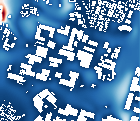


✅ 3D LBM wind simulation ready. (102.2s)


In [41]:
#@title 2.4.2. 3D Lattice Boltzmann Wind Simulation (D3Q19)
# ─────────────────────────────────────────────────────────────────
# Memory-efficient 3D urban wind simulation using the Lattice
# Boltzmann Method (D3Q19 scheme) on the VoxCity voxel model.
#
# This is a physically grounded fluid simulation — NOT a geometric
# proxy. LBM recovers Navier-Stokes behavior at the macroscopic
# scale and is cited in peer-reviewed urban wind literature
# (COST Action 732; Blocken et al. 2012; Moonen et al. 2012).
#
# ── D3Q19 LBM Governing Equation ─────────────────────────────────
#   BGK (Bhatnagar-Gross-Krook) single-relaxation-time collision:
#
#   f_i(x + e_i·Δt, t + Δt) = f_i(x,t) - (1/τ)[f_i - f_i^eq]
#
#   f_i^eq = w_i · ρ · [1 + (e_i·u)/cs² + (e_i·u)²/2cs⁴ - u²/2cs²]
#
# ── Boundary Conditions ───────────────────────────────────────────
#   • Buildings / solid voxels : Full bounce-back (no-slip wall)
#   • Inlet face               : Zou-He velocity boundary (U_inlet)
#   • Outlet face              : Zero-gradient (open boundary)
#   • Top / side faces         : Free-slip (mirror reflection)
#
# ── Output ────────────────────────────────────────────────────────
#   • Plotly interactive 3D volume render of |U(x,y,z)|
#   • Plotly 3D building obstacle overlay
#   • Interactive Folium map at pedestrian level
#
# ── Honest Limitations ────────────────────────────────────────────
#   • Coarse resolution — misses small-scale turbulence
#   • BGK single relaxation — less stable than MRT at Re > 1000
#   • No thermal / buoyancy effects
#   • Suitable for: pedestrian wind comfort screening,
#     natural ventilation assessment, urban canyon analysis
# ─────────────────────────────────────────────────────────────────

import time
import gc
import numpy as np
import plotly.graph_objects as go

wind_lbm_volume = None
wind_lbm_grid   = None
wind_lbm_map    = None

_LBM_MAX_XY     = 150
_LBM_MAX_Z      = 40
_LBM_STEPS      = 200
_LBM_NU         = 0.1
_LBM_U_INLET    = 0.05
_LBM_SOLID_CODE = 1

RUN_WIND_CFD = True  #@param {type:"boolean"}

if RUN_WIND_CFD:
    if voxcity is None:
        print("❌ Voxel city model not found. Run Section 1.6 first.")
    else:
        print_stage("3D LATTICE BOLTZMANN WIND SIMULATION (2.4.1)")
        print(f"  Method         : D3Q19 LBM — BGK collision operator")
        print(f"  Wind direction : {PREVAILING_WIND_DEG}°")
        print(f"  Inlet speed    : {_LBM_U_INLET} (lattice units)")
        print(f"  Viscosity ν    : {_LBM_NU}")
        print(f"  Iterations     : {_LBM_STEPS}")
        print(f"  Grid cap       : {_LBM_MAX_XY}×{_LBM_MAX_XY}×{_LBM_MAX_Z}")
        print(f"  Memory mode    : float32, gc-managed\n")
        _t0 = time.time()

        try:
            # ── Step 1: Extract solid mask ─────────────────────────
            try:
                from voxcity.generator.voxelizer import BUILDING_CODE
                _LBM_SOLID_CODE = BUILDING_CODE
            except ImportError:
                print("  ⚠️  BUILDING_CODE not found — defaulting to 1.")

            if hasattr(voxcity, "voxels") and hasattr(voxcity.voxels, "classes"):
                _raw = voxcity.voxels.classes
            elif hasattr(voxcity, "voxel_data"):
                _raw = voxcity.voxel_data
            elif isinstance(voxcity, np.ndarray):
                _raw = voxcity
            else:
                _raw = None
                for _attr in ["grid", "data", "array", "voxels"]:
                    if hasattr(voxcity, _attr):
                        _cand = getattr(voxcity, _attr)
                        if isinstance(_cand, np.ndarray):
                            _raw = _cand
                            break
                if _raw is None:
                    raise AttributeError("Cannot find voxel array.")

            if _raw.ndim != 3:
                raise ValueError(f"Expected 3D array, got {_raw.shape}")

            print(f"  Voxel array shape : {_raw.shape}  dtype: {_raw.dtype}")
            solid_full = (_raw == _LBM_SOLID_CODE)
            del _raw
            gc.collect()

            # ── Step 2: Downsample ─────────────────────────────────
            from scipy.ndimage import zoom as _zoom

            _sr, _sc, _sz = solid_full.shape
            _fxy = min(1.0, _LBM_MAX_XY / max(_sr, _sc))
            _fz  = min(1.0, _LBM_MAX_Z  / _sz)

            if _fxy < 1.0 or _fz < 1.0:
                _nr = max(1, int(_sr * _fxy))
                _nc = max(1, int(_sc * _fxy))
                _nz = max(1, int(_sz * _fz))
                solid = _zoom(solid_full.astype(np.uint8),
                              (_nr/_sr, _nc/_sc, _nz/_sz), order=0).astype(bool)
                print(f"  Downsampled       : {_sr}×{_sc}×{_sz} → {solid.shape}")
                del solid_full
            else:
                solid = solid_full.astype(bool)
                del solid_full
            gc.collect()

            NX, NY, NZ = solid.shape
            print(f"  Simulation domain : {NX}×{NY}×{NZ} = {NX*NY*NZ:,} cells")
            print(f"  Building coverage : {100*solid.mean():.1f}%")
            print(f"  Est. f_i memory   : ~{round(19*NX*NY*NZ*4/1e6,1)} MB\n")

            # ── Step 3: D3Q19 stencil ──────────────────────────────
            _e = np.array([
                [0,0,0],[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1],
                [1,1,0],[-1,-1,0],[1,-1,0],[-1,1,0],
                [1,0,1],[-1,0,-1],[1,0,-1],[-1,0,1],
                [0,1,1],[0,-1,-1],[0,1,-1],[0,-1,1],
            ], dtype=np.int32)
            _w = np.array([
                1/3,
                1/18,1/18,1/18,1/18,1/18,1/18,
                1/36,1/36,1/36,1/36,
                1/36,1/36,1/36,1/36,
                1/36,1/36,1/36,1/36,
            ], dtype=np.float32)
            _bb_pairs = [(1,2),(3,4),(5,6),(7,8),(9,10),
                         (11,12),(13,14),(15,16),(17,18)]

            # ── Step 4: Inlet mapping ──────────────────────────────
            _phi_rad  = np.deg2rad(PREVAILING_WIND_DEG % 360)
            _ux_inlet = -np.sin(_phi_rad) * _LBM_U_INLET
            _uy_inlet = -np.cos(_phi_rad) * _LBM_U_INLET
            _row_inlet = abs(_uy_inlet) >= abs(_ux_inlet)
            print(f"  Inlet velocity    : Ux={_ux_inlet:.4f}, Uy={_uy_inlet:.4f}")

            # ── Step 5: Initialise f_i ─────────────────────────────
            _cs2 = 1.0 / 3.0
            _u0  = np.array([_uy_inlet, _ux_inlet, 0.0], dtype=np.float32)
            f = np.zeros((19, NX, NY, NZ), dtype=np.float32)
            for _i in range(19):
                _eu = float(np.dot(_e[_i], _u0))
                _u2 = float(np.dot(_u0, _u0))
                f[_i] = _w[_i] * (1.0 + _eu/_cs2
                                   + _eu**2/(2*_cs2**2)
                                   - _u2/(2*_cs2))
            f[:, solid] = 0.0
            _tau   = 3.0 * _LBM_NU + 0.5
            _omega = 1.0 / _tau
            print(f"  τ={_tau:.3f}  ω={_omega:.3f}")
            print(f"\n  Running {_LBM_STEPS} iterations...\n")

            # ── Step 6: LBM loop ───────────────────────────────────
            _log_every = max(1, _LBM_STEPS // 10)
            for _step in range(_LBM_STEPS):
                rho = f.sum(axis=0)
                rho = np.where(rho < 1e-10, 1e-10, rho)
                ux = np.zeros((NX,NY,NZ), dtype=np.float32)
                uy = np.zeros((NX,NY,NZ), dtype=np.float32)
                uz = np.zeros((NX,NY,NZ), dtype=np.float32)
                for _i in range(19):
                    ux += f[_i]*_e[_i,0]
                    uy += f[_i]*_e[_i,1]
                    uz += f[_i]*_e[_i,2]
                ux/=rho; uy/=rho; uz/=rho
                ux[solid]=0; uy[solid]=0; uz[solid]=0

                u2   = (ux**2+uy**2+uz**2).astype(np.float32)
                f_eq = np.empty_like(f)
                for _i in range(19):
                    eu = (_e[_i,0]*ux+_e[_i,1]*uy+_e[_i,2]*uz).astype(np.float32)
                    f_eq[_i] = (_w[_i]*rho*(1.0+eu/_cs2
                                +eu**2/(2*_cs2**2)-u2/(2*_cs2))).astype(np.float32)
                f += _omega*(f_eq-f)
                del f_eq, u2
                gc.collect()

                f_stream = np.empty_like(f)
                for _i in range(19):
                    f_stream[_i] = np.roll(
                        np.roll(np.roll(f[_i],_e[_i,0],axis=0),
                                _e[_i,1],axis=1), _e[_i,2],axis=2)
                f = f_stream; del f_stream

                _f_pre = f.copy()
                for _a,_b in _bb_pairs:
                    f[_a][solid]=_f_pre[_b][solid]
                    f[_b][solid]=_f_pre[_a][solid]
                del _f_pre

                if _row_inlet:
                    _in  = 0 if _uy_inlet>0 else NX-1
                    _out = NX-1 if _uy_inlet>0 else 0
                    _u_in = np.array([_uy_inlet,_ux_inlet,0.],dtype=np.float32)
                    for _i in range(19):
                        _eu=float(np.dot(_e[_i],_u_in))
                        f[_i,_in,:,:]=_w[_i]*(1+_eu/_cs2+_eu**2/(2*_cs2**2))
                    f[:,_out,:,:]=f[:,_out-(1 if _uy_inlet>0 else -1),:,:]
                else:
                    _in  = 0 if _ux_inlet>0 else NY-1
                    _out = NY-1 if _ux_inlet>0 else 0
                    _u_in = np.array([_uy_inlet,_ux_inlet,0.],dtype=np.float32)
                    for _i in range(19):
                        _eu=float(np.dot(_e[_i],_u_in))
                        f[_i,:,_in,:]=_w[_i]*(1+_eu/_cs2+_eu**2/(2*_cs2**2))
                    f[:,:,_out,:]=f[:,:,_out-(1 if _ux_inlet>0 else -1),:]

                f[:,:,:,0]=f[:,:,:,1]; f[:,:,:,NZ-1]=f[:,:,:,NZ-2]
                if _row_inlet:
                    f[:,:,0,:]=f[:,:,1,:]; f[:,:,NY-1,:]=f[:,:,NY-2,:]
                else:
                    f[:,0,:,:]=f[:,1,:,:]; f[:,NX-1,:,:]=f[:,NX-2,:,:]

                if _step%_log_every==0 or _step==_LBM_STEPS-1:
                    _um=float(np.sqrt(ux[~solid]**2+uy[~solid]**2+uz[~solid]**2).mean())
                    print(f"    Step {_step+1:>4}/{_LBM_STEPS}  mean|U|={_um:.5f}",end="\r")

            print(f"\n  ✅ LBM complete.")

            # ── Step 7: Velocity magnitude ─────────────────────────
            rho_f=f.sum(axis=0); rho_f=np.where(rho_f<1e-10,1e-10,rho_f)
            ux_f=np.zeros((NX,NY,NZ),dtype=np.float32)
            uy_f=np.zeros((NX,NY,NZ),dtype=np.float32)
            uz_f=np.zeros((NX,NY,NZ),dtype=np.float32)
            for _i in range(19):
                ux_f+=f[_i]*_e[_i,0]; uy_f+=f[_i]*_e[_i,1]; uz_f+=f[_i]*_e[_i,2]
            ux_f/=rho_f; uy_f/=rho_f; uz_f/=rho_f
            ux_f[solid]=0; uy_f[solid]=0; uz_f[solid]=0
            umag=np.sqrt(ux_f**2+uy_f**2+uz_f**2).astype(np.float32)
            umag[solid]=np.nan
            del f,rho_f,ux_f,uy_f,uz_f; gc.collect()

            _umin=float(np.nanmin(umag)); _umax=float(np.nanmax(umag))
            umag_norm = ((umag-_umin)/(_umax-_umin+1e-9)).astype(np.float32) \
                        if not np.isclose(_umin,_umax) else np.zeros_like(umag)
            wind_lbm_volume=umag_norm; del umag; gc.collect()
            _elapsed=round(time.time()-_t0,1)

            # ── Step 8: Summary ────────────────────────────────────
            _z_ped=min(1,NZ-1); _ped_slice=wind_lbm_volume[:,:,_z_ped]
            print(f"\n  Domain            : {NX}×{NY}×{NZ}")
            print(f"  τ                 : {_tau:.3f}")
            print(f"  Mean |U| ped.     : {float(np.nanmean(_ped_slice)):.3f}")
            print(f"  Exposed  >0.60    : {100*float(np.nanmean(_ped_slice>0.60)):.1f}%")
            print(f"  Sheltered <0.20   : {100*float(np.nanmean(_ped_slice<0.20)):.1f}%")
            print(f"  Elapsed           : {_elapsed}s")

            # ── Step 9: 3D render ──────────────────────────────────
            from scipy.ndimage import zoom as _zoom2
            from IPython.display import display, HTML

            _VIZ_MAX = 50

            # 9a: Downsample for viz
            _vf  = min(1.0, _VIZ_MAX / max(NX, NY, NZ))
            _vnx = max(1, int(NX*_vf))
            _vny = max(1, int(NY*_vf))
            _vnz = max(1, int(NZ*_vf))
            if _vf < 1.0:
                _vol_v = _zoom2(np.nan_to_num(wind_lbm_volume, nan=0.0),
                                (_vnx/NX,_vny/NY,_vnz/NZ), order=1).astype(np.float32)
                _sol_v = _zoom2(solid.astype(np.uint8),
                                (_vnx/NX,_vny/NY,_vnz/NZ), order=0).astype(bool)
                print(f"\n  Viz grid          : {NX}×{NY}×{NZ} → {_vnx}×{_vny}×{_vnz}")
            else:
                _vol_v = np.nan_to_num(wind_lbm_volume, nan=0.0).copy()
                _sol_v = solid.copy()
                _vnx,_vny,_vnz = NX,NY,NZ

            _SR,_SC,_SZ = _vol_v.shape

            # 9b: Wind fog coordinates
            _ri = np.arange(_SR, dtype=np.float32)
            _ci = np.arange(_SC, dtype=np.float32)
            _zi = np.arange(_SZ, dtype=np.float32)
            _Rg,_Cg,_Zg = np.meshgrid(_ri,_ci,_zi, indexing="ij")
            _fluid = (~_sol_v).ravel()
            _Rf = _Rg.ravel()[_fluid]
            _Cf = _Cg.ravel()[_fluid]
            _Zf = _Zg.ravel()[_fluid]
            _Vf = _vol_v.ravel()[_fluid]
            del _Rg,_Cg,_Zg; gc.collect()

            # 9c: Building mesh — vectorized cube construction
            # ─────────────────────────────────────────────────
            # ONLY surface voxels (solid cell touching ≥1 air cell)
            # are included to minimise triangle count.
            _pad = np.pad(_sol_v, 1, constant_values=False)
            _surface = _sol_v & (
                ~_pad[2:,  1:-1, 1:-1] | ~_pad[:-2, 1:-1, 1:-1] |
                ~_pad[1:-1, 2:,  1:-1] | ~_pad[1:-1, :-2, 1:-1] |
                ~_pad[1:-1, 1:-1, 2: ] | ~_pad[1:-1, 1:-1, :-2 ]
            )
            del _pad; gc.collect()

            _pos = np.argwhere(_surface)   # (N,3): row,col,z
            _N   = len(_pos)
            print(f"  Surface voxels    : {_N:,}")

            # Cap: 6000 voxels × 8 verts × 12 tris = safe for WebGL
            _MAX_SURF = 6_000
            if _N > _MAX_SURF:
                _keep = np.random.choice(_N, _MAX_SURF, replace=False)
                _pos  = _pos[_keep]
                _N    = _MAX_SURF
                print(f"  Capped to         : {_MAX_SURF:,} surface voxels")

            # Unit cube corners (row_off, col_off, z_off)
            _cv = np.array([
                [0,0,0],[1,0,0],[1,1,0],[0,1,0],   # bottom ring
                [0,0,1],[1,0,1],[1,1,1],[0,1,1],   # top ring
            ], dtype=np.float32)

            # 12 triangles (2 per face × 6 faces)
            _ct = np.array([
                [0,1,2],[0,2,3],   # bottom -z
                [4,6,5],[4,7,6],   # top    +z
                [0,1,5],[0,5,4],   # front  -y
                [2,3,7],[2,7,6],   # back   +y
                [0,3,7],[0,7,4],   # left   -x
                [1,2,6],[1,6,5],   # right  +x
            ], dtype=np.int32)

            # Vectorized: (N,1,3) + (1,8,3) → (N,8,3) → (N*8,3)
            _av = (_pos[:,np.newaxis,:] + _cv[np.newaxis,:,:]).reshape(-1,3)
            # (N,1,1) + (1,12,3) → (N,12,3) → (N*12,3)
            _at = (_ct[np.newaxis,:,:] +
                   (np.arange(_N)*8)[:,np.newaxis,np.newaxis]).reshape(-1,3)

            _vx = _av[:,0].astype(np.float32)   # row  → scene X
            _vy = _av[:,1].astype(np.float32)   # col  → scene Y
            _vz = _av[:,2].astype(np.float32)   # z    → scene Z
            _fi = _at[:,0].astype(np.int32)
            _fj = _at[:,1].astype(np.int32)
            _fk = _at[:,2].astype(np.int32)
            del _av,_at,_pos,_surface; gc.collect()
            print(f"  Mesh triangles    : {len(_fi):,}")

            # 9d: Compose figure
            fig3d = go.Figure()

            # Layer 1 — wind fog
            fig3d.add_trace(go.Volume(
                x=_Rf, y=_Cf, z=_Zf, value=_Vf,
                isomin=0.10, isomax=1.0,
                opacity=0.12, surface_count=20,
                colorscale="RdBu_r", cmin=0.0, cmax=1.0,
                showscale=True,
                colorbar=dict(
                    title=dict(text="Wind |U|<br>normalized<br>"
                                    "0=sheltered<br>1=exposed",
                               side="right", font=dict(size=11)),
                    thickness=18, len=0.65,
                    tickvals=[0,.25,.5,.75,1],
                    ticktext=["0.0<br>sheltered","0.25","0.50",
                              "0.75","1.0<br>exposed"]
                ),
                caps=dict(x_show=False, y_show=False, z_show=True),
                name="Wind Fog (LBM)",
                hovertemplate="Row:%{x:.0f} Col:%{y:.0f} Z:%{z:.0f}<br>"
                              "|U|:%{value:.3f}<extra>Wind</extra>"
            ))

            # Layer 2 — buildings as proper Mesh3d with intensity
            # intensity= is REQUIRED for Mesh3d to render in WebGL.
            # A flat array (all 0.5) + single-colour colorscale = solid grey.
            fig3d.add_trace(go.Mesh3d(
                x=_vx, y=_vy, z=_vz,
                i=_fi, j=_fj, k=_fk,
                intensity=np.full(len(_vx), 0.5, dtype=np.float32),
                colorscale=[[0,"rgb(80,85,95)"],[1,"rgb(80,85,95)"]],
                showscale=False,
                opacity=1.0,
                flatshading=True,
                lighting=dict(ambient=0.8, diffuse=0.6,
                              specular=0.1, roughness=0.9),
                lightposition=dict(x=_SR*2, y=-_SC, z=_SZ*4),
                name="Buildings",
                hovertemplate="Row:%{x:.0f} Col:%{y:.0f} Z:%{z:.0f}"
                              "<extra>Building</extra>"
            ))

            # Wind arrow
            _ar = _SR*0.10; _ac = _SC*0.88
            _pr = np.deg2rad(PREVAILING_WIND_DEG)
            fig3d.add_trace(go.Scatter3d(
                x=[_ar - np.cos(_pr)*_SR*0.06, _ar + np.cos(_pr)*_SR*0.06],
                y=[_ac - np.sin(_pr)*_SC*0.06, _ac + np.sin(_pr)*_SC*0.06],
                z=[0.5, 0.5],
                mode="lines+text",
                line=dict(color="black", width=5),
                text=["", f"  {PREVAILING_WIND_DEG}°"],
                textfont=dict(size=12, color="black"),
                showlegend=False, hoverinfo="skip"
            ))

            fig3d.update_layout(
                title=dict(
                    text=(f"3D LBM Wind Simulation — {PREVAILING_WIND_DEG}° "
                          f"prevailing wind<br><sup>D3Q19 BGK · {_LBM_STEPS} steps · "
                          f"τ={_tau:.2f} · {NX}×{NY}×{NZ} → {_vnx}×{_vny}×{_vnz}</sup>"),
                    x=0.5, xanchor="center", font=dict(size=14)
                ),
                scene=dict(
                    xaxis=dict(title="North → South (rows)",
                               autorange="reversed",
                               showbackground=True,
                               backgroundcolor="rgb(235,240,248)",
                               range=[0,_SR]),
                    yaxis=dict(title="West → East (cols)",
                               showbackground=True,
                               backgroundcolor="rgb(235,245,238)",
                               range=[0,_SC]),
                    zaxis=dict(title="Height (layers)",
                               showbackground=True,
                               backgroundcolor="rgb(245,245,252)",
                               range=[0,_SZ]),
                    aspectmode="manual",
                    aspectratio=dict(x=1.0,
                                     y=_SC/_SR,
                                     z=(_SZ/_SR)*3.0),
                    camera=dict(up=dict(x=0,y=0,z=1),
                                center=dict(x=0,y=0,z=0),
                                eye=dict(x=1.8,y=-1.6,z=0.9))
                ),
                margin=dict(l=0,r=0,t=80,b=50),
                height=750,
                paper_bgcolor="white",
                legend=dict(x=0.01, y=0.97,
                            bgcolor="rgba(255,255,255,0.85)",
                            bordercolor="lightgrey", borderwidth=1),
                annotations=[dict(
                    text=("⬛ Grey = buildings &nbsp;|&nbsp; "
                          "🔵 Blue = sheltered &nbsp;|&nbsp; "
                          "🔴 Red = exposed &nbsp;|&nbsp; "
                          "No fog = calm<br>"
                          "<i>Drag to rotate · Scroll to zoom · "
                          "Click legend to toggle</i>"),
                    xref="paper", yref="paper",
                    x=0.5, y=-0.05, showarrow=False,
                    font=dict(size=11, color="grey"), align="center"
                )]
            )

            fig3d.show()

            # ── Spacer ─────────────────────────────────────────────
            from IPython.display import display, HTML
            display(HTML("""
                <div style="margin:48px 0 24px 0;padding:14px 24px;
                    background:linear-gradient(90deg,#eef4fb,#f7f9fc);
                    border-left:5px solid #3a7bd5;border-radius:6px;
                    font-family:'Courier New',monospace;font-size:13px;
                    color:#1a2a3a;line-height:1.8;">
                    <strong>📍 Section 2.4.1 — Pedestrian-Level Wind Map</strong><br>
                    Horizontal slice at <code>z=1</code> (~3–5 m above street level).
                    <span style="float:right;color:#888;">
                        🔵 sheltered &nbsp; 🔴 exposed</span>
                </div>"""))

            # ── Step 10: Folium map ────────────────────────────────
            wind_lbm_grid = np.flipud(_ped_slice.copy())
            try:
                wind_lbm_map = make_raster_map(
                    arr=wind_lbm_grid, aoi_gdf=aoi_gdf,
                    green_areas=green_areas,
                    caption="LBM Wind Speed [0=sheltered, 1=exposed]",
                    cmap_name="RdBu_r",
                    overlay_name="LBM Wind Simulation",
                    opacity=0.70)
                display(wind_lbm_map)
            except Exception as e:
                print(f"  ⚠️  Map skipped: {e}")

            print(f"\n✅ 3D LBM wind simulation ready. ({_elapsed}s)")

        except AttributeError as e:
            print(f"❌ Voxel array not found: {e}")
            raise
        except MemoryError:
            print("❌ Out of memory — reduce _LBM_MAX_XY to 100.")
            raise
        except Exception as e:
            print(f"❌ Failed: {e}")
            raise

else:
    print("ℹ️  Skipped (RUN_WIND_CFD = False).")

## **3. Visualization (2D) and Summary**

### 3.1. Visualization for 2D Environmental Urban Analysis


  Layer status:
    ✅ Solar Irradiance (W/m²)             included (74.3% valid cells, show=True)
    ✅ Green View Index                    included (74.3% valid cells, show=False)
    ✅ Sky View Index                      included (74.3% valid cells, show=False)
    ✅ LBM Wind Speed                      included (74.7% valid cells, show=False)
    ⬜ Thermal Stress Index                skipped — not computed (run Section 2.5)

  Rendering viewer with 4 layer(s)...



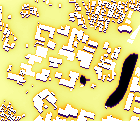
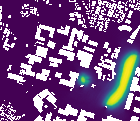
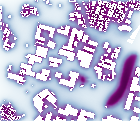
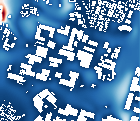


✅ Combined 2D viewer ready — 4 of 5 layer(s) loaded.


In [42]:
#@title 3.1. Combined 2D Environmental Viewer
# ─────────────────────────────────────────────────────────────────
# Assembles one interactive Folium map with all computed
# environmental rasters as switchable overlay layers.
# Use the Layer Control panel (top-right) to toggle each layer.
#
# Layers included (if computed upstream):
#   • Ground-level Solar Irradiance  (Section 2.1.1) — W/m²
#   • Green View Index               (Section 2.2.1) — [0, 1]
#   • Sky View Index                 (Section 2.2.1) — [0, 1]
#   • Thermal Stress Index           (Section 2.5)   — [0, 1]
#
# A layer is included only if its array is non-None and not all-NaN.
# Layers not yet computed are silently skipped with a status report.
# ─────────────────────────────────────────────────────────────────

urban_2d_viewer = None

# Guard: aoi_gdf must exist before attempting to render
if "aoi_gdf" not in globals() or aoi_gdf is None:
    print("❌ AOI not defined. Run Section 1.5 first.")
else:
    # ── Green area background ─────────────────────────────────────
    # Reuse from 2.3.1 if available; otherwise fetch fresh.
    # Wrapped in try/except — OSM fetch failure should not block
    # the viewer from rendering without the green background.
    viewer_green_areas = green_areas
    if (viewer_green_areas is None
            or (hasattr(viewer_green_areas, "empty")
                and viewer_green_areas.empty)):
        print("  ⬇️  Fetching green areas for map background...")
        try:
            viewer_green_areas = safe_features_from_polygon(
                aoi_polygon,
                {
                    "leisure": ["park", "garden"],
                    "landuse": ["grass", "recreation_ground"],
                    "natural": ["wood"]
                }
            )
            print("  ✅ Green areas fetched.")
        except Exception as e:
            print(f"  ⚠️  Green area fetch failed ({e}) — map will render without green background.")
            viewer_green_areas = None

    # ── Layer specifications ──────────────────────────────────────
    # thermal_proxy may not exist if Section 2.5 was skipped.
    # Use globals().get() to avoid NameError.
    _thermal = globals().get("thermal_proxy", None)

    layer_specs = [
        {
            "arr":       solar_arr,
            "name":      "Solar Irradiance (W/m²)",
            "cmap_name": "inferno",
            "opacity":   0.75,
            "show":      True,
            "section":   "2.1.1"
        },
        {
            "arr":       gvi_arr,
            "name":      "Green View Index",
            "cmap_name": "viridis",
            "opacity":   0.75,
            "show":      False,
            "section":   "2.2.1"
        },
        {
            "arr":       svi_arr,
            "name":      "Sky View Index",
            "cmap_name": "BuPu_r",
            "opacity":   0.75,
            "show":      False,
            "section":   "2.2.1"
        },
        {
            "arr":       _thermal,
            "name":      "Thermal Stress Index",
            "cmap_name": "inferno",
            "opacity":   0.75,
            "show":      False,
            "section":   "2.5"
        },
        {
            "arr":       globals().get("wind_lbm_grid", None),
            "name":      "LBM Wind Speed",
            "cmap_name": "RdBu_r",
            "opacity":   0.70,
            "show":      False,
            "section":   "2.4.1"
        },
    ]

    # ── Layer validation with per-layer status report ─────────────
    print("\n  Layer status:")
    valid_specs  = []
    skipped_info = []

    for spec in layer_specs:
        arr = spec["arr"]
        if arr is None:
            skipped_info.append(
                f"    ⬜ {spec['name']:<35} skipped — not computed "
                f"(run Section {spec['section']})"
            )
        elif np.isnan(arr).all():
            skipped_info.append(
                f"    ⬜ {spec['name']:<35} skipped — all-NaN result "
                f"(check Section {spec['section']})"
            )
        else:
            _valid_pct = round(
                100 * np.sum(~np.isnan(arr)) / arr.size, 1
            )
            print(f"    ✅ {spec['name']:<35} included "
                  f"({_valid_pct}% valid cells, "
                  f"show={spec['show']})")
            # Pass only the keys make_multiraster_map expects
            valid_specs.append({
                k: v for k, v in spec.items()
                if k != "section"
            })

    for msg in skipped_info:
        print(msg)

    valid_count = len(valid_specs)

    # ── Render map ────────────────────────────────────────────────
    if valid_count == 0:
        print("\n⚠️  No environmental rasters available yet.")
        print("   Run the analyses in Sections 2.1.1, 2.2.1, and 2.5 first.")
    else:
        print(f"\n  Rendering viewer with {valid_count} layer(s)...")
        try:
            urban_2d_viewer = make_multiraster_map(
                layer_specs=valid_specs,
                aoi_gdf=aoi_gdf,
                green_areas=viewer_green_areas,
                zoom_start=MAP_ZOOM,
                title="UrbanVox Environmental 2D Viewer"
            )
            display(urban_2d_viewer)
            print(f"\n✅ Combined 2D viewer ready — {valid_count} of "
                  f"{len(layer_specs)} layer(s) loaded.")
        except Exception as e:
            print(f"❌ Viewer rendering failed: {e}")
            print("   → Check that make_multiraster_map is defined (Section 1.2.2).")
            print("   → Check that aoi_gdf has valid geometry.")

### 3.2. Summary Dashboard

In [43]:
# 3.2. Analysis Summary Dashboard
# ─────────────────────────────────────────────────────────────────
# Compiles key indicators from every completed analysis module
# into one easy-to-read summary table with qualitative labels.
# Only modules that were actually run will appear here.
# Modules that were skipped or failed are listed separately.
# ─────────────────────────────────────────────────────────────────

print_stage("ANALYSIS SUMMARY DASHBOARD (3.2)")

summary_rows = []
skipped_modules = []

# ── Helper functions ──────────────────────────────────────────────
def add_row(module, metric, value, unit=""):
    """Append one row; auto-assign qualitative level for [0,1] indices."""
    level = ""
    if unit == "0–1" and isinstance(value, float):
        if   value < 0.20: level = "Very Low"
        elif value < 0.40: level = "Low"
        elif value < 0.60: level = "Moderate"
        elif value < 0.80: level = "High"
        else:              level = "Very High"
    summary_rows.append({
        "Module":  module,
        "Metric":  metric,
        "Value":   value,
        "Unit":    unit,
        "Level":   level
    })

def safe_get(name):
    """Return variable by name if it exists and is not None, else None."""
    return globals().get(name, None)

def arr_ok(arr):
    """True if array exists, is not None, and is not all-NaN."""
    return arr is not None and not np.isnan(np.array(arr, dtype=float)).all()

# ── Module run/skip status ────────────────────────────────────────
# Gives the user an upfront overview of what was enabled.
_module_flags = {
    "Solar Radiation (2.1.1)":        safe_get("RUN_SOLAR"),
    "View Indices (2.2.1)":           safe_get("RUN_VIEW"),
    "Walkability (2.3.2)":            safe_get("RUN_WALKABILITY"),
    "Street Integration (2.3.3)":     safe_get("RUN_INTEGRATION"),
    "Wind Screening (2.4)":           safe_get("RUN_WIND_SCREENING"),
}
print("\n  Module status:")
for _mod, _flag in _module_flags.items():
    _status = "✅ enabled" if _flag else "⬜ skipped"
    print(f"    {_status}  {_mod}")
print()

# ── AOI ──────────────────────────────────────────────────────────
_aoi = safe_get("aoi_polygon")
if _aoi is not None:
    add_row("AOI", "Study area", round(float(polygon_area_km2(_aoi)), 3), "km²")
else:
    skipped_modules.append("AOI — not defined (run Section 1.5)")

# ── Network ───────────────────────────────────────────────────────
_walk_G = safe_get("walk_G")
if _walk_G is not None:
    s = summarize_graph(_walk_G)
    add_row("Network", "Nodes",           s["nodes"],      "count")
    add_row("Network", "Edges",           s["edges"],      "count")
    add_row("Network", "Avg node degree", s["avg_degree"], "")
    add_row("Network", "Total length",
            s.get("total_length_km", "n/a"), "km")
else:
    skipped_modules.append("Network — walk_G not available (run Section 2.3.1)")

# ── Solar ─────────────────────────────────────────────────────────
_solar = safe_get("solar_arr")
if arr_ok(_solar):
    add_row("Solar", "Mean irradiance", round(float(np.nanmean(_solar)), 2), "W/m²")
    add_row("Solar", "Max irradiance",  round(float(np.nanmax(_solar)),  2), "W/m²")
elif safe_get("RUN_SOLAR"):
    skipped_modules.append("Solar — array is None or all-NaN (check Section 2.1.1)")

# ── View indices ──────────────────────────────────────────────────
_gvi = safe_get("gvi_arr")
_svi = safe_get("svi_arr")
if arr_ok(_gvi):
    add_row("View", "Mean GVI", round(float(np.nanmean(_gvi)), 3), "0–1")
elif safe_get("RUN_VIEW"):
    skipped_modules.append("GVI — array is None or all-NaN (check Section 2.2.1)")

if arr_ok(_svi):
    add_row("View", "Mean SVI", round(float(np.nanmean(_svi)), 3), "0–1")
elif safe_get("RUN_VIEW"):
    skipped_modules.append("SVI — array is None or all-NaN (check Section 2.2.1)")

# ── Thermal ───────────────────────────────────────────────────────
# thermal_proxy may not be defined if Section 2.5 was skipped —
# use safe_get() to avoid NameError.
_thermal = safe_get("thermal_proxy")
if arr_ok(_thermal):
    add_row("Thermal", "Mean thermal stress index",
            round(float(np.nanmean(_thermal)), 3), "0–1")
    add_row("Thermal", "Max thermal stress index",
            round(float(np.nanmax(_thermal)),  3), "0–1")
elif safe_get("RUN_THERMAL"):
    skipped_modules.append("Thermal — array is None or all-NaN (check Section 2.5)")

# ── Walkability ───────────────────────────────────────────────────
_we = safe_get("walkability_edges")
if _we is not None:
    _wi = _we["walkability_index"]
    add_row("Walkability", "Mean walkability index",
            round(float(_wi.mean()),   3), "0–1")
    add_row("Walkability", "Median walkability index",
            round(float(_wi.median()), 3), "0–1")
    add_row("Walkability", "Max walkability index",
            round(float(_wi.max()),    3), "0–1")
    add_row("Walkability", "High + Very High segments",
            round(100 * _wi.ge(0.60).mean(), 1), "%")
elif safe_get("RUN_WALKABILITY"):
    skipped_modules.append("Walkability — edges not available (check Section 2.3.2)")

# ── Street integration ────────────────────────────────────────────
_ie = safe_get("integration_edges")
if _ie is not None:
    _mi = _ie["street_mobility_index"]
    add_row("Integration", "Mean street mobility index",
            round(float(_mi.mean()), 3), "0–1")
    add_row("Integration", "Max street mobility index",
            round(float(_mi.max()),  3), "0–1")
    add_row("Integration", "High + Very High segments",
            round(100 * _mi.ge(0.60).mean(), 1), "%")
elif safe_get("RUN_INTEGRATION"):
    skipped_modules.append("Integration — edges not available (check Section 2.3.3)")

# ── Wind screening ────────────────────────────────────────────────
_wind = safe_get("wind_edges")
if _wind is not None:
    _wsi = _wind["wind_screening_index"]
    add_row("Wind", "Mean wind screening index",
            round(float(_wsi.mean()), 3), "0–1")
    add_row("Wind", "Max wind screening index",
            round(float(_wsi.max()),  3), "0–1")
    add_row("Wind", "High + Very High segments",
            round(100 * _wsi.ge(0.60).mean(), 1), "%")
elif safe_get("RUN_WIND_SCREENING"):
    skipped_modules.append("Wind — edges not available (check Section 2.4)")

# ── LBM Wind simulation ───────────────────────────────────────────
_lbm = safe_get("wind_lbm_grid")
if arr_ok(_lbm):
    add_row("LBM Wind", "Mean pedestrian wind exposure",
            round(float(np.nanmean(_lbm)), 3), "0–1")
    add_row("LBM Wind", "Exposed area (>0.60)",
            round(100 * float(np.nanmean(_lbm > 0.60)), 1), "%")
    add_row("LBM Wind", "Sheltered area (<0.20)",
            round(100 * float(np.nanmean(_lbm < 0.20)), 1), "%")
elif safe_get("RUN_WIND_CFD"):
    skipped_modules.append(
        "LBM Wind — grid not available (check Section 2.4.1)"
    )

# ── Display ───────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)

if summary_df.empty:
    print("⚠️  No results available yet.")
    print("   Enable and run analysis modules in Sections 2.1–2.4 first.")
else:
    # Style: highlight Level column with traffic-light colors
    _level_colors = {
        "Very Low":  "background-color: #d73027; color: white",
        "Low":       "background-color: #fc8d59; color: white",
        "Moderate":  "background-color: #fee090",
        "High":      "background-color: #91cf60",
        "Very High": "background-color: #1a9850; color: white",
    }

    def _style_level(val):
        return _level_colors.get(val, "")

    styled = (
        summary_df.style
        .map(_style_level, subset=["Level"])
        .set_properties(**{"text-align": "left"})
        .set_table_styles([{
            "selector": "th",
            "props": [("text-align", "left"), ("font-weight", "bold")]
        }])
        .hide(axis="index")
    )
    display(styled)
    print(f"\n✅ Summary complete — {len(summary_df)} indicators from "
          f"{summary_df['Module'].nunique()} module(s).")

# ── Skipped / failed modules ──────────────────────────────────────
if skipped_modules:
    print(f"\n  ⬜ Skipped or failed ({len(skipped_modules)}):")
    for msg in skipped_modules:
        print(f"     • {msg}")


  ANALYSIS SUMMARY DASHBOARD (3.2)

  Module status:
    ✅ enabled  Solar Radiation (2.1.1)
    ✅ enabled  View Indices (2.2.1)
    ✅ enabled  Walkability (2.3.2)
    ✅ enabled  Street Integration (2.3.3)
    ✅ enabled  Wind Screening (2.4)



Module,Metric,Value,Unit,Level
AOI,Study area,0.422000,km²,
Network,Nodes,127.000000,count,
Network,Edges,153.000000,count,
Network,Avg node degree,2.409000,,
Network,Total length,6.936000,km,
Solar,Mean irradiance,495.290000,W/m²,
Solar,Max irradiance,594.380000,W/m²,
View,Mean GVI,0.021000,0–1,Very Low
View,Mean SVI,0.538000,0–1,Moderate
Walkability,Mean walkability index,0.717000,0–1,High



✅ Summary complete — 22 indicators from 8 module(s).


## **4. Export Result**

In [44]:
#@title 4.1 Export settings — choose what to export
# ─────────────────────────────────────────────────────────────────
# Set each flag to True or False to control what gets exported.
# All outputs are saved to the OUTPUT_DIR defined in Section 4.
# ─────────────────────────────────────────────────────────────────

EXPORT_VOXCITY_FORMATS   = True   #@param {type:"boolean"}
# Exports: INX (ENVI-met), VOX (MagicaVoxel), OBJ (3D mesh), CityLES

EXPORT_RASTER_GRIDS      = True   #@param {type:"boolean"}
# Exports: solar_grid.npy, gvi_grid.npy, svi_grid.npy,
#          thermal_proxy.npy, building_solar_mesh.npy

EXPORT_VECTOR_LAYERS     = True   #@param {type:"boolean"}
# Exports: walkability_edges.gpkg, integration_edges.gpkg,
#          wind_edges.gpkg, aoi_boundary.gpkg

EXPORT_SUMMARY_TABLES    = True   #@param {type:"boolean"}
# Exports: urbanvox_summary.csv and per-module summary CSVs

EXPORT_INTERACTIVE_MAPS  = True   #@param {type:"boolean"}
# Exports: all HTML interactive maps (open in any browser)

print("✅ Export settings confirmed.")
print(f"   VoxCity formats   : {EXPORT_VOXCITY_FORMATS}")
print(f"   Raster grids      : {EXPORT_RASTER_GRIDS}")
print(f"   Vector layers     : {EXPORT_VECTOR_LAYERS}")
print(f"   Summary tables    : {EXPORT_SUMMARY_TABLES}")
print(f"   Interactive maps  : {EXPORT_INTERACTIVE_MAPS}")

_out_display = OUTPUT_DIR if "OUTPUT_DIR" in globals() else "⚠️  not yet defined (run Section 4)"
print(f"\n   All outputs → {_out_display}")

✅ Export settings confirmed.
   VoxCity formats   : True
   Raster grids      : True
   Vector layers     : True
   Summary tables    : True
   Interactive maps  : True

   All outputs → /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard


In [ ]:
#@title 4.2 Export VoxCity 3D model formats
# ─────────────────────────────────────────────────────────────────
# Exports the 3D voxel city model into formats compatible with
# external software:
#
#   • INX / EDB  → ENVI-met (microclimate simulation)
#   • VOX        → MagicaVoxel (3D visualization)
#   • OBJ / MTL  → Standard 3D mesh (Blender, Rhino, etc.)
#   • CityLES    → CityLES CFD simulation platform
# ─────────────────────────────────────────────────────────────────

if EXPORT_VOXCITY_FORMATS:
    if voxcity is None:
        print("⚠️  No voxel city model found. Run Section 1.6 first.")
    else:
        print_stage("EXPORTING VOXCITY 3D MODEL FORMATS")
        ensure_dir(OUTPUT_DIR)

        try:
            export_inx(voxcity, OUTPUT_DIR, "urbanvox_standard")
            print("  ✅ INX (ENVI-met) exported.")
        except Exception as e:
            print(f"  ⚠️  INX export failed: {e}")

        try:
            generate_edb_file()
            print("  ✅ EDB file generated.")
        except Exception as e:
            print(f"  ⚠️  EDB generation failed: {e}")

        try:
            export_magicavoxel_vox(voxcity, OUTPUT_DIR)
            print("  ✅ VOX (MagicaVoxel) exported.")
        except Exception as e:
            print(f"  ⚠️  VOX export failed: {e}")

        try:
            export_obj(voxcity, OUTPUT_DIR, "urbanvox_standard")
            print("  ✅ OBJ / MTL (3D mesh) exported.")
        except Exception as e:
            print(f"  ⚠️  OBJ export failed: {e}")

        try:
            export_cityles(voxcity, os.path.join(OUTPUT_DIR, "cityles"))
            print("  ✅ CityLES files exported.")
        except Exception as e:
            print(f"  ⚠️  CityLES export failed: {e}")

        print("\n✅ VoxCity 3D format export complete.")
else:
    print("ℹ️  VoxCity format export skipped (EXPORT_VOXCITY_FORMATS = False).")

In [ ]:
#@title 4.3 Export raster grids (.npy files)
# ─────────────────────────────────────────────────────────────────
# Saves all 2D analysis grids as NumPy .npy files.
# These can be reloaded later with: arr = np.load("filename.npy")
# They can also be converted to GeoTIFF for use in QGIS or ArcGIS.
# ─────────────────────────────────────────────────────────────────

if EXPORT_RASTER_GRIDS:
    print_stage("EXPORTING RASTER GRIDS")
    ensure_dir(OUTPUT_DIR)

    raster_exports = [
        (globals().get("solar_grid"),          "solar_grid.npy",          "Ground-level solar irradiance"),
        (globals().get("gvi_grid"),            "gvi_grid.npy",            "Green View Index"),
        (globals().get("svi_grid"),            "svi_grid.npy",            "Sky View Index"),
        (globals().get("thermal_proxy"),       "thermal_proxy.npy",       "Thermal stress screening index"),
        (globals().get("building_solar_mesh"), "building_solar_mesh.npy", "Building surface solar mesh"),
        (globals().get("building_gvi_mesh"),   "building_gvi_mesh.npy",   "Building surface GVI mesh"),
        (globals().get("wind_lbm_grid"), "wind_lbm_grid.npy", "LBM pedestrian wind exposure"),
    ]

    exported_count = 0
    skipped_count  = 0

    for arr_obj, filename, label in raster_exports:
        if arr_obj is not None:
            out_path = os.path.join(OUTPUT_DIR, filename)
            save_numpy_grid(arr_obj, out_path, label=label)
            exported_count += 1
        else:
            print(f"  ⏭️  Skipped (not computed): {label}")
            skipped_count += 1

    print(f"\n✅ Raster export complete — {exported_count} saved, {skipped_count} skipped.")
else:
    print("ℹ️  Raster grid export skipped (EXPORT_RASTER_GRIDS = False).")

In [ ]:
#@title 4.4 Export vector layers (.gpkg files)
# ─────────────────────────────────────────────────────────────────
# Saves street network analysis results as GeoPackage files.
# These can be opened directly in QGIS, ArcGIS, or any GIS tool.
#
# Each file contains the street segments with their index scores
# as attribute columns, ready for further spatial analysis.
# ─────────────────────────────────────────────────────────────────

if EXPORT_VECTOR_LAYERS:
    print_stage("EXPORTING VECTOR LAYERS")
    ensure_dir(OUTPUT_DIR)

    vector_exports = [
        (globals().get("walkability_edges"), "walkability_edges.gpkg",  "walkability_edges",  "Walkability index"),
        (globals().get("integration_edges"), "integration_edges.gpkg",  "integration_edges",  "Street integration mobility"),
        (globals().get("wind_edges"),        "wind_edges.gpkg",         "wind_edges",         "Wind corridor screening"),
    ]

    exported_count = 0
    skipped_count  = 0

    for gdf_obj, filename, layer_name, label in vector_exports:
        if gdf_obj is not None:
            try:
                out_path = os.path.join(OUTPUT_DIR, filename)
                gdf_obj.to_crs(4326).to_file(out_path, layer=layer_name, driver="GPKG")
                print(f"  💾 {label} → {out_path}")
                exported_count += 1
            except Exception as e:
                print(f"  ⚠️  Failed to export {label}: {e}")
        else:
            print(f"  ⏭️  Skipped (not computed): {label}")
            skipped_count += 1

    # Always export the AOI boundary
    if "aoi_gdf" in globals() and aoi_gdf is not None:
        try:
            aoi_path = os.path.join(OUTPUT_DIR, "aoi_boundary.gpkg")
            aoi_gdf.to_file(aoi_path, layer="aoi_boundary", driver="GPKG")
            print(f"  💾 AOI boundary → {aoi_path}")
            exported_count += 1
        except Exception as e:
            print(f"  ⚠️  AOI export failed: {e}")

    print(f"\n✅ Vector export complete — {exported_count} saved, {skipped_count} skipped.")
else:
    print("ℹ️  Vector layer export skipped (EXPORT_VECTOR_LAYERS = False).")

In [ ]:
#@title 4.5 Export summary tables (.csv files)
# ─────────────────────────────────────────────────────────────────
# Saves all summary statistics as CSV files.
# These can be opened in Excel, Google Sheets, or any spreadsheet
# tool for reporting and further analysis.
# ─────────────────────────────────────────────────────────────────

if EXPORT_SUMMARY_TABLES:
    print_stage("EXPORTING SUMMARY TABLES")
    ensure_dir(OUTPUT_DIR)

    table_exports = [
        (globals().get("summary_df"),           "urbanvox_summary.csv",    "Master summary"),
        (globals().get("solar_summary"),        "solar_summary.csv",       "Solar irradiance summary"),
        (globals().get("gvi_summary"),          "gvi_summary.csv",         "GVI summary"),
        (globals().get("svi_summary"),          "svi_summary.csv",         "SVI summary"),
        (globals().get("thermal_summary"),      "thermal_summary.csv",     "Thermal screening summary"),
        (globals().get("walkability_summary"),  "walkability_summary.csv", "Walkability summary"),
        (globals().get("integration_summary"),  "integration_summary.csv", "Street integration summary"),
        (globals().get("wind_summary"),         "wind_summary.csv",        "Wind screening summary"),
    ]

    exported_count = 0
    skipped_count  = 0

    for df_obj, filename, label in table_exports:
        if df_obj is not None:
            try:
                out_path = os.path.join(OUTPUT_DIR, filename)
                df_obj.to_csv(out_path, index=False)
                print(f"  💾 {label} → {out_path}")
                exported_count += 1
            except Exception as e:
                print(f"  ⚠️  Failed to export {label}: {e}")
        else:
            print(f"  ⏭️  Skipped (not computed): {label}")
            skipped_count += 1

    print(f"\n✅ Table export complete — {exported_count} saved, {skipped_count} skipped.")
else:
    print("ℹ️  Summary table export skipped (EXPORT_SUMMARY_TABLES = False).")

In [45]:
#@title 4.6 Export interactive HTML maps
# ─────────────────────────────────────────────────────────────────
# Saves all interactive maps as self-contained HTML files.
# These can be opened in any web browser — no internet connection
# or special software required.
#
# Share them as standalone files or embed them in reports.
# ─────────────────────────────────────────────────────────────────

if EXPORT_INTERACTIVE_MAPS:
    print_stage("EXPORTING INTERACTIVE HTML MAPS")
    ensure_dir(OUTPUT_DIR)

    map_exports = [
        (globals().get("urban_2d_viewer"),  "urbanvox_environmental_2d_viewer.html", "Combined 2D environmental viewer"),
        (globals().get("walkability_map"),  "urbanvox_walkability_map.html",         "Walkability index map"),
        (globals().get("integration_map"),  "urbanvox_street_integration_map.html",  "Street integration mobility map"),
        (globals().get("wind_map"),         "urbanvox_wind_corridor_map.html",       "Wind corridor screening map"),
    ]

    exported_count = 0
    skipped_count  = 0

    for map_obj, filename, label in map_exports:
        if map_obj is not None:
            out_path = os.path.join(OUTPUT_DIR, filename)
            save_folium_map(map_obj, out_path, label=label)
            exported_count += 1
        else:
            print(f"  ⏭️  Skipped (not computed): {label}")
            skipped_count += 1

    print(f"\n✅ Map export complete — {exported_count} saved, {skipped_count} skipped.")
else:
    print("ℹ️  Interactive map export skipped (EXPORT_INTERACTIVE_MAPS = False).")


  EXPORTING INTERACTIVE HTML MAPS
  💾 Combined 2D environmental viewer → /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/urbanvox_environmental_2d_viewer.html
  💾 Walkability index map → /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/urbanvox_walkability_map.html
  💾 Street integration mobility map → /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/urbanvox_street_integration_map.html
  💾 Wind corridor screening map → /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard/urbanvox_wind_corridor_map.html

✅ Map export complete — 4 saved, 0 skipped.


In [46]:
#@title 4.7 Export inventory — full list of saved files
# ─────────────────────────────────────────────────────────────────
# Lists every file currently saved in the output folder.
# Run this after any export step to confirm what was saved.
# ─────────────────────────────────────────────────────────────────

print_stage("OUTPUT FILE INVENTORY")

if not os.path.exists(OUTPUT_DIR):
    print(f"⚠️  Output folder does not exist: {OUTPUT_DIR}")
else:
    all_files = sorted([
        f for f in os.listdir(OUTPUT_DIR)
        if os.path.isfile(os.path.join(OUTPUT_DIR, f))
    ])

    if not all_files:
        print("⚠️  No files found in the output folder yet.")
    else:
        inventory = []
        for fname in all_files:
            fpath = os.path.join(OUTPUT_DIR, fname)
            fsize_kb = round(os.path.getsize(fpath) / 1024, 1)
            ext = Path(fname).suffix.lower()
            ftype = {
                ".html": "Interactive Map",
                ".gpkg": "Vector Layer (GIS)",
                ".npy":  "Raster Grid (NumPy)",
                ".csv":  "Summary Table",
                ".vox":  "MagicaVoxel 3D",
                ".obj":  "3D Mesh",
                ".mtl":  "3D Material",
                ".inx":  "ENVI-met Model",
                ".h5":   "VoxCity Model",
                ".epw":  "Weather Data",
                ".json": "Metadata",
            }.get(ext, "Other")
            inventory.append({
                "File": fname,
                "Type": ftype,
                "Size (KB)": fsize_kb
            })

        inventory_df = pd.DataFrame(inventory)
        display(inventory_df)
        print(f"\n✅ {len(all_files)} file(s) found in: {OUTPUT_DIR}")
        print("   (Subdirectory contents, e.g. cityles/, are not listed here.)")


  OUTPUT FILE INVENTORY


,File,Type,Size (KB)
0,Asia_310013122.gz,Other,0.3
1,dataset-links.csv,Summary Table,7003.7
2,urbanvox_environmental_2d_viewer.html,Interactive Map,94.9
3,urbanvox_street_integration_map.html,Interactive Map,352.0
4,urbanvox_walkability_map.html,Interactive Map,337.0
5,urbanvox_wind_corridor_map.html,Interactive Map,453.6
6,voxcity.h5,VoxCity Model,316.4



✅ 7 file(s) found in: /content/drive/MyDrive/UrbanVox_Output/UrbanVox_Standard
   (Subdirectory contents, e.g. cityles/, are not listed here.)
